# EDA : la codification PAY_n = 1

**Objectif** : comprendre ce que signifie la codification 1, présente presque uniquement en M-1 (PAY_1), et vérifier si elle apporte une nouvelle lecture du jeu de données (population contentieuse, autres statuts, features).

**Cadre**
- Étude limitée dans le temps.
- Rappel : une première tentative de correction (niveau 3, version abandonnée) remettait PAY_1 à 2 et plaçait des clients au contentieux à tort.
- **Garde-fou** : ce notebook décrit et conclut, il ne corrige ni le nettoyage ni la définition du contentieux. Toute proposition qui touche au CTX est appliquée ensuite dans `05_02_EDA_contentieux` et documentée comme une révision.
- Méthode : description avec les montants d'abord (sans `dpnm`), puis validation avec `dpnm` sur le **train uniquement**.
- Convention : `PAY_n`, `PAY_AMTn` et `BILL_AMT(n+1)` vont ensemble ; un paiement peut être enregistré avec un mois de décalage (regarder 2 mois).

Les analyses exploratoires sur la codification 1 menées dans l'EDA lab sont conservées en **annexe**, telles quelles.

> **Mise à jour du 03/10/2026** : le recodage du mois de transition, que ce notebook recommandait de garder dans le contentieux, est désormais appliqué dans le **niveau 5 du nettoyage** (`02_01_nettoyage`, `cleaned5`), avec les autres corrections de codification issues du contentieux. Les sections 1 à 6 restent l'étude d'origine, menée sur `cleaned3` ; la **section 7** contrôle `cleaned5` avec les mêmes tests ; `STATUT_CTX`, `SOUS_STATUT_CTX` et `PAY_1_recode` y sont des colonnes de travail, absentes du dataset (voir `docs/colonnes_creees.md`).

## 0. Données et hypothèses

**Hypothèses de départ sur la codification 1**
1. alerte ou relance interne sur le compte ;
2. décalage de mise à jour : paiement effectué (par exemple en supérette) mais pas encore comptabilisé ;
3. statut d'attente, notamment à la sortie d'un retard ;
4. vrai retard d'un mois, conforme à la documentation du dataset.

**Données**
- **Sections 1 à 3** (nature de la codification 1) : données brutes `creditcard_pret_ingestion` (30 000 lignes, toutes les codifications 1 d'origine), comme l'EDA lab ; la section 2 les compare aux niveaux de nettoyage `cleaned1` à `cleaned3`.
- **Sections 4 à 6** (lien avec le contentieux, validation, décisions) : `cleaned3`, périmètre S12, même split que `05_02_EDA_contentieux` ; `dpnm` sur le train uniquement.
- **Section 7** (contrôle du niveau 5) : `cleaned4` (avant les corrections de codification) et `cleaned5` (après), même périmètre S12 et mêmes clients de train que les sections 4 à 6 ; `dpnm` sur le train uniquement.
- **Annexe** : données brutes moins les 4 paiements supérieurs à 1 000 000 NT$, comme l'EDA lab. Certaines cellules y utilisent `dpnm` sur toutes les lignes (test compris) : elles ne servent à fixer aucune règle.

**Périmètre `S12`** : clients avec un encours positif en M-1 (`BILL_AMT1 > 0`) et un plafond inférieur ou égal à 500 000 NT$ (clients atypiques à gros plafond retirés).

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split

# Retrouve la racine du projet (là où se trouve le dossier 'data')
current_dir = Path.cwd()
root_dir = next(p for p in [current_dir] + list(current_dir.parents) if (p / "data").exists())

pay_cols = [f'PAY_{i}' for i in range(1, 7)]
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
pay_amt_cols = [f'PAY_AMT{i}' for i in range(1, 7)]

# Données brutes (30 000 lignes, seules EDUCATION et MARRIAGE harmonisées)
df_brut = pd.read_csv(root_dir / "data" / "creditcard_pret_ingestion.csv")

# Données nettoyées (niveau 3) et périmètre S12 : encours positif à M-1 et plafond <= 500 000 NT$
df_c3 = pd.read_csv(root_dir / "data" / "cleaned3_creditcard.csv")
df_s12 = df_c3[(df_c3['BILL_AMT1'] > 0) & (df_c3['LIMIT_BAL'] <= 500000)].copy()

# Split commun avec 05_02_EDA_contentieux
df_train, df_test = train_test_split(df_s12, test_size=0.2, stratify=df_s12['dpnm'], random_state=42)
print(f"Brut : {len(df_brut)} | cleaned3 : {len(df_c3)} | S12 : {len(df_s12)} | train : {len(df_train)} | test : {len(df_test)}")


Brut : 30000 | cleaned3 : 29055 | S12 : 27202 | train : 21761 | test : 5441


In [100]:
# Fonctions recopiées de 05_02_EDA_contentieux (corriger_faux_codage : section 3, recodage_pay1 : section 6.1,
# statut_ctx_regle2 : section 6 ; version révisée du 27/09/2026, recodage du mois de transition révisé le 30/09/2026) :
# ne pas les modifier ici, toute évolution de la règle se fait dans 05_02.

def corriger_faux_codage(d, neutraliser_endormis=False):
    # Faux 2 : entrée au CTX (PAY_m >= 2 alors que PAY_(m+1) < 2) alors que la facture exigible,
    # BILL_AMT(m+1), est nulle ou négative
    # - compte endormi (ni paiement le mois précédent, ni encours 2 mois avant) : compte récent sous surveillance ;
    #   code 2 conservé (règle 1), ou neutralisé pour le calcul du CTX si neutraliser_endormis=True (définition 2 révisée)
    # - client qui venait de payer ou avait un encours : faux codage, les codes >= 2 posés sur une facture nulle
    #   sont remplacés par le dernier code sain précédant l'entrée
    codes = d[pay_cols].copy()
    faux_codage = pd.Series(False, index=d.index)
    surveillance = pd.Series(False, index=d.index)
    for m in range(1, 6):
        faux_2 = (d[f'PAY_{m}'] >= 2) & (d[f'PAY_{m+1}'] < 2) & (d[f'BILL_AMT{m+1}'] <= 0)
        paiement_avant = d[f'PAY_AMT{m+1}'] > 0
        # encours 2 mois avant le 2 non observable pour une entrée en M-5
        encours_avant = d[f'BILL_AMT{m+2}'] > 0 if m + 2 <= 6 else pd.Series(False, index=d.index)
        fc = faux_2 & (paiement_avant | encours_avant)
        surveillance |= faux_2 & ~fc
        faux_codage |= fc
        # Neutralisation de la série de codes >= 2 sur facture nulle, à partir du mois d'entrée
        # (faux codage toujours ; compte endormi seulement si neutraliser_endormis=True)
        a_corriger = (faux_2 if neutraliser_endormis else fc).copy()
        for k in range(m, 0, -1):
            a_corriger &= (d[f'PAY_{k}'] >= 2) & (d[f'BILL_AMT{k+1}'] <= 0)
            codes.loc[a_corriger, f'PAY_{k}'] = d.loc[a_corriger, f'PAY_{m+1}']
    d_corrige = d.copy()
    d_corrige[pay_cols] = codes
    return d_corrige, faux_codage, surveillance

def recodage_pay1(d):
    # Mois de transition : sortie apparente du CTX entre M-2 et M-1 (PAY_2 >= 2, PAY_1 <= 1)
    transition = (d['PAY_2'] >= 2) & (d['PAY_1'] <= 1)
    # Ratio de paiement de M-1 sur la facture précédente (en %), 0 si pas de facture positive
    ratio = (d['PAY_AMT1'] / d['BILL_AMT2'].where(d['BILL_AMT2'] > 0) * 100).fillna(0)
    # Aucun paiement sur 2 mois (décalage d'enregistrement des paiements)
    sans_paiement_2_mois = (d['PAY_AMT1'] == 0) & (d['PAY_AMT2'] == 0)
    # Absence de paiement significative seulement si une facture était exigible les 2 mois (BILL_AMT3 en M-2, BILL_AMT2 en M-1)
    factures_exigibles = (d['BILL_AMT3'] > 0) & (d['BILL_AMT2'] > 0)
    # Code d'avant le retard : premier code < 2 avant la série de retards (PAY_3, PAY_4...) ; 0 si la série remonte jusqu'à M-6 ;
    # -2 remplacé par -1 (un client qui avait une dette ne sort pas en « pas de consommation »), code > 0 ramené à 0 (section 6.1)
    code_avant = pd.Series(0, index=d.index)
    a_chercher = pd.Series(True, index=d.index)
    for k in range(3, 7):
        trouve = a_chercher & (d[f'PAY_{k}'] < 2)
        code_avant[trouve] = d.loc[trouve, f'PAY_{k}']
        a_chercher &= ~trouve
    code_avant = code_avant.clip(upper=0).replace(-2, -1)

    pay1_recode = np.select(
        [transition & sans_paiement_2_mois & factures_exigibles, transition & (ratio >= 90)],
        [2, code_avant],
        default=d['PAY_1'],
    )
    return pd.Series(pay1_recode, index=d.index)


def statut_ctx_regle2(d):
    # 1. Correction des faux codages (identique à la règle 1), 2. recodage du mois de transition (révisé, section 6.1)
    #    (révision : les codes 2 posés sur facture nulle d'un compte endormi sont neutralisés, flag SURVEILLANCE_RECENTE conservé)
    d_corrige, faux_codage, surveillance = corriger_faux_codage(d, neutraliser_endormis=True)
    pay1 = recodage_pay1(d_corrige)
    codes = d_corrige[pay_cols].copy()
    codes['PAY_1'] = pay1

    # 3. Retard payé : PAY_1 >= 2 mais facture payée à 90 % ou plus en M-1 ou en M-2
    ratio_m1 = (d['PAY_AMT1'] / d['BILL_AMT2'].where(d['BILL_AMT2'] > 0) * 100).fillna(0)
    ratio_m2 = (d['PAY_AMT2'] / d['BILL_AMT3'].where(d['BILL_AMT3'] > 0) * 100).fillna(0)
    retard_paye = (pay1 >= 2) & ((ratio_m1 >= 90) | (ratio_m2 >= 90))
    #    Retard payé qui termine une série (PAY_2 >= 2) : passage au CTX avéré, sortie présumée en M
    #    Retard payé isolé (PAY_2 < 2) : régularisation présumée d'un retard isolé
    retard_paye_serie = retard_paye & (codes['PAY_2'] >= 2)
    retard_paye_isole = retard_paye & ~retard_paye_serie

    # 4. Historique (séries de codes >= 2 terminées avant M-1) :
    #    série d'au moins 2 mois = passage au CTX ; 2 isolé = retard régularisé ;
    #    2 isolé en M-6 = passage au CTX par défaut (M-7 inconnu)
    retard = (codes >= 2).values
    passage_ctx = np.zeros(len(d), bool)
    retard_regularise = np.zeros(len(d), bool)
    mois_sortie = np.full(len(d), -1.0)
    mois_regularisation = np.full(len(d), -1.0)
    for i, r in enumerate(retard):
        k = 1
        while k < 6:
            if r[k] and not r[k - 1]:
                fin = k
                while fin + 1 < 6 and r[fin + 1]:
                    fin += 1
                # k = mois du retour sous 2 (1 = M-1), séries parcourues de la plus récente à la plus ancienne
                if fin > k or fin == 5:
                    if not passage_ctx[i]:
                        mois_sortie[i] = k
                    passage_ctx[i] = True
                else:
                    if not retard_regularise[i]:
                        mois_regularisation[i] = k
                    retard_regularise[i] = True
                k = fin + 1
            else:
                k += 1
    passage_ctx = pd.Series(passage_ctx, index=d.index)
    retard_regularise = pd.Series(retard_regularise, index=d.index)

    statut = pd.Series(np.select(
        [retard_paye, pay1 >= 2, passage_ctx, retard_regularise],
        ['Retard considéré régularisé M-1', 'CTX', 'Sorti', 'Retard régularisé'],
        default='Jamais CTX',
    ), index=d.index)

    duree = (codes >= 2).cumprod(axis=1).sum(axis=1)
    sous_statut = statut.copy()
    sous_statut[(statut == 'CTX') & (duree == 6)] = 'CTX 6 mois'
    sous_statut[(statut == 'CTX') & (duree.between(2, 5))] = 'CTX 2 à 5 mois'
    sous_statut[(statut == 'CTX') & (duree == 1)] = 'CTX entrée en M-1'
    sous_statut[retard_paye_serie] = 'Retard considéré régularisé M-1 (série)'
    sous_statut[retard_paye_isole] = 'Retard considéré régularisé M-1 (isolé)'

    # FLAG_CTX = 1 : client au CTX à M ou passé par le CTX ; MOIS_SORTIE_CTX = -1 : pas de sortie (au CTX à M ou jamais au CTX)
    # -> client au CTX à M = FLAG_CTX = 1 et MOIS_SORTIE_CTX = -1 (retiré du dataset ML)
    mois_sortie = pd.Series(mois_sortie, index=d.index)
    mois_sortie[statut == 'CTX'] = -1
    # Retard payé en série = sortie du CTX présumée en M : MOIS_SORTIE_CTX = 0 (tête d'échelle)
    mois_sortie[retard_paye_serie] = 0
    # Retard payé isolé = régularisation présumée au plus tard en M : MOIS_SORTIE_RETARD = 0 (tête d'échelle)
    mois_regularisation = pd.Series(mois_regularisation, index=d.index)
    mois_regularisation[retard_paye_isole] = 0
    mois_regularisation[statut == 'CTX'] = np.nan
    retard_regularise = retard_regularise | retard_paye_isole

    return pd.DataFrame({
        'PAY_1_recode': pay1,
        'STATUT_CTX': statut,
        'SOUS_STATUT_CTX': sous_statut,
        'MOIS_SORTIE_CTX': mois_sortie,
        'FLAG_CTX': (passage_ctx | (statut == 'CTX') | retard_paye_serie).astype(int),
        'MOIS_SORTIE_RETARD': mois_regularisation,
        'FLAG_RETARD': (retard_regularise & (statut != 'CTX')).astype(int),
        'SURVEILLANCE_RECENTE': surveillance.astype(int),
        'FAUX_CODAGE': faux_codage.astype(int),
    })


statuts_train = statut_ctx_regle2(df_train)


## 1. Où est la codification 1 ?
*Population : données brutes (30 000 lignes), sans `dpnm`.*
Répartition de la codification 1 par mois, dans les données brutes et dans `cleaned3`. Pourquoi est-elle presque absente de PAY_2 à PAY_6 ?
Piste : PAY_1 viendrait d'une table de gestion « à chaud » et PAY_2 à PAY_6 d'historiques apurés. Si c'est le cas, PAY_1 n'a pas le même sens que les autres mois.

In [101]:
# 1. Répartition des codifications PAY_n par mois (%)
repartition = pd.DataFrame({col: df_brut[col].value_counts(normalize=True) * 100 for col in pay_cols}).fillna(0)
display(repartition.loc[[-2, -1, 0, 1, 2, 3]].round(2).rename_axis('Codification PAY_n'))

# 2. Que deviennent les clients d'un mois à l'autre ?
# Lecture : pour le mois M-k, on part des clients selon leur codification du mois précédent (M-(k+1)),
# et on regarde leur codification en M-k. Chaque ligne fait 100 %.
# On compare M-1 aux autres mois : si la codification 1 était un vrai « retard d'un mois », il existerait aussi dans l'historique.
depuis_sain, depuis_retard = [], []
for k in range(1, 6):
    avant, apres = df_brut[f'PAY_{k+1}'], df_brut[f'PAY_{k}']
    sain, retard = avant <= 0, avant >= 2
    depuis_sain.append({'Mois': f'M-{k}', 'Nb clients': sain.sum(),
                        'Reste sain (%)': (apres[sain] <= 0).mean() * 100,
                        'Passe à 1 (%)': (apres[sain] == 1).mean() * 100,
                        'Passe à 2 ou plus (%)': (apres[sain] >= 2).mean() * 100})
    depuis_retard.append({'Mois': f'M-{k}', 'Nb clients': retard.sum(),
                          'Redescend à une codification saine (%)': (apres[retard] <= 0).mean() * 100,
                          'Passe à 1 (%)': (apres[retard] == 1).mean() * 100,
                          'Reste à 2 ou plus (%)': (apres[retard] >= 2).mean() * 100})

print("A. Clients SAINS le mois précédent (PAY <= 0) : que deviennent-ils ?")
display(pd.DataFrame(depuis_sain).set_index('Mois').round(1))
print("B. Clients EN RETARD le mois précédent (PAY >= 2) : que deviennent-ils ?")
display(pd.DataFrame(depuis_retard).set_index('Mois').round(1))


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
Codification PAY_n,,,,,,
-2,9.20,12.61,13.62,14.49,15.15,16.32
-1,18.95,20.17,19.79,18.96,18.46,19.13
0,49.12,52.43,52.55,54.85,56.49,54.29
1,12.29,0.09,0.01,0.01,0.00,0.00
2,8.89,13.09,12.73,10.53,8.75,9.22
3,1.07,1.09,0.80,0.60,0.59,0.61


A. Clients SAINS le mois précédent (PAY <= 0) : que deviennent-ils ?


,Nb clients,Reste sain (%),Passe à 1 (%),Passe à 2 ou plus (%)
Mois,,,,
M-1,25562,88.9,7.2,3.9
M-2,25787,94.2,0.1,5.7
M-3,26490,93.9,0.0,6.1
M-4,27032,95.4,0.0,4.6
M-5,26921,96.8,0.0,3.2


B. Clients EN RETARD le mois précédent (PAY >= 2) : que deviennent-ils ?


,Nb clients,Redescend à une codification saine (%),Passe à 1 (%),Reste à 2 ou plus (%)
Mois,,,,
M-1,4410,10.1,41.4,48.5
M-2,4209,30.3,0.0,69.6
M-3,3508,26.3,0.0,73.7
M-4,2968,24.0,0.0,75.9
M-5,3079,31.6,0.0,68.4


**Comment lire les tableaux A et B** : une ligne = un mois ; on part des clients selon leur codification du mois précédent et on regarde leur codification ce mois-ci. On compare la ligne M-1 aux lignes M-2 à M-5.

**Constats**
- La codification 1 n'existe pratiquement qu'en M-1. Dans l'historique (M-2 à M-5), un client sain passe directement à 2 (tableau A), et un client en retard redescend à une codification saine ou reste à 2 ou plus (tableau B) : jamais de passage par 1.
- **Tableau A** : en M-1, les clients sains passent à 2 à peu près comme les autres mois ; la codification 1 vient surtout de clients qui, les autres mois, **seraient restés sains**. Chez eux, elle ne remplace pas un retard : elle s'ajoute (alerte ou statut, voir section 3).
- **Tableau B** : en M-1, nettement moins de clients redescendent à une codification saine, et nettement moins restent à 2 ou plus, que les autres mois. La différence part sur la codification 1 : elle prend la place **à la fois de sorties et de retards maintenus**.
- La codification 1 se comporte donc comme un **statut provisoire du dernier mois**, que l'historique a ensuite tranché (sortie ou maintien du retard). C'est cohérent avec l'hypothèse d'un PAY_1 issu d'une table « à chaud » et de PAY_2 à PAY_6 issus d'historiques consolidés : PAY_1 n'a pas tout à fait le même sens que les autres mois.

## 2. Qu'est-ce qui précède la codification 1 ?
*Population : données brutes, puis `cleaned1` à `cleaned3` pour voir ce que le nettoyage a corrigé.*  
Découpage des PAY_1 = 1 selon PAY_2 :
- codification saine avant (-2, -1, 0) : signal d'entrée en difficulté ?
- PAY_n >= 2 avant : mois de transition, déjà recodé par `recodage_pay1` dans le contentieux.

In [102]:
def groupe_code1(d):
    # Groupes selon la codification qui précède PAY_1 = 1
    return pd.Series(np.select(
        [(d['PAY_1'] == 1) & (d['PAY_2'] <= 0), (d['PAY_1'] == 1) & (d['PAY_2'] == 1), (d['PAY_1'] == 1) & (d['PAY_2'] >= 2)],
        ['1 après codification saine', '1 après 1', '1 après retard'], default='autre'), index=d.index)

niveaux = {'brut': df_brut}
for k in [1, 2, 3]:
    niveaux[f'cleaned{k}'] = pd.read_csv(root_dir / "data" / f"cleaned{k}_creditcard.csv")

print("PAY_1 = 1 selon PAY_2, à chaque niveau de nettoyage :")
display(pd.DataFrame({nom: groupe_code1(d).value_counts() for nom, d in niveaux.items()})
        .drop('autre').fillna(0).astype(int).rename_axis('Groupe'))


PAY_1 = 1 selon PAY_2, à chaque niveau de nettoyage :


,brut,cleaned1,cleaned2,cleaned3
Groupe,,,,
1 après 1,28,27,6,6
1 après codification saine,1836,1246,682,12
1 après retard,1824,1824,1824,1824


**Constats**
- Dans les données brutes, les codifications 1 se partagent presque à égalité entre « 1 après une codification saine » et « 1 après un retard ».
- Le nettoyage (niveaux 1 à 3) corrige la quasi-totalité des « 1 après une codification saine » et **aucun « 1 après un retard »**. Les codifications 1 restantes dans `cleaned3` sont presque toutes des mois de transition après un retard : ce sont celles que le contentieux recode avec `recodage_pay1`.
- La suite de l'étude porte donc surtout sur les « 1 après un retard ».

## 3. Que disent les montants ?
*Population : données brutes, sans `dpnm`. Les groupes de codification 1 sont comparés à des groupes de référence sans codification 1.*  
Pour chaque groupe de la section 2 : facture exigible (`BILL_AMT2`), paiements de M-1 et de M-2 (`PAY_AMT1`, `PAY_AMT2`), ratio de paiement, encours de M-1 (`BILL_AMT1`).
Quelle hypothèse de la section 0 les montants confirment-ils ou écartent-ils ? **Description sans `dpnm`.**

In [103]:
def groupe_transition(d):
    return pd.Series(np.select(
        [(d['PAY_1'] == 1) & (d['PAY_2'] <= 0), (d['PAY_1'] == 1) & (d['PAY_2'] >= 2),
         (d['PAY_1'] <= 0) & (d['PAY_2'] <= 0), (d['PAY_1'] >= 2) & (d['PAY_2'] <= 0),
         (d['PAY_1'] <= 0) & (d['PAY_2'] >= 2), (d['PAY_1'] >= 2) & (d['PAY_2'] >= 2)],
        ['1 après codification saine', '1 après retard',
         'réf. sain -> sain', 'réf. sain -> retard (entrée en M-1)',
         'réf. retard -> sain (sortie en M-1)', 'réf. retard -> retard'], default='autre'), index=d.index)

d = df_brut
grp = groupe_transition(d)
ratio_m1 = d['PAY_AMT1'] / d['BILL_AMT2'].where(d['BILL_AMT2'] > 0) * 100
ratio_m2 = d['PAY_AMT2'] / d['BILL_AMT3'].where(d['BILL_AMT3'] > 0) * 100
inactif_avant = (d[[f'BILL_AMT{k}' for k in range(2, 7)]] <= 0).all(axis=1) & (d[[f'PAY_AMT{k}' for k in range(2, 7)]] == 0).all(axis=1)

montants = pd.DataFrame({
    'Nb clients': d.groupby(grp).size(),
    'Facture de M-1 nulle (%)': (d['BILL_AMT2'] <= 0).groupby(grp).mean() * 100,
    'Paiement en M-1 (%)': (d['PAY_AMT1'] > 0).groupby(grp).mean() * 100,
    'Paiement en M-2 (%)': (d['PAY_AMT2'] > 0).groupby(grp).mean() * 100,
    'Ratio de M-1 (médiane)': ratio_m1.groupby(grp).median(),
    'Facture de M-1 payée à 90 % (%)': (ratio_m1 >= 90).groupby(grp).mean() * 100,
    'Facture de M-2 payée à 90 % (%)': (ratio_m2 >= 90).groupby(grp).mean() * 100,
    'Encours M-1 nul (%)': (d['BILL_AMT1'] <= 0).groupby(grp).mean() * 100,
    'Compte inactif de M-6 à M-2 (%)': inactif_avant.groupby(grp).mean() * 100,
    'Utilisation du plafond M-1 (médiane %)': (d['BILL_AMT1'] / d['LIMIT_BAL'] * 100).groupby(grp).median(),
}).drop('autre', errors='ignore').round(1)
display(montants.rename_axis('Groupe'))


,Nb clients,Facture de M-1 nulle (%),Paiement en M-1 (%),Paiement en M-2 (%),Ratio de M-1 (médiane),Facture de M-1 payée à 90 % (%),Facture de M-2 payée à 90 % (%),Encours M-1 nul (%),Compte inactif de M-6 à M-2 (%),Utilisation du plafond M-1 (médiane %)
Groupe,,,,,,,,,,
1 après codification saine,1836,62.9,38.2,38.2,100.0,36.5,31.0,91.9,29.7,0.0
1 après retard,1824,0.0,42.7,78.3,0.0,0.1,4.1,0.1,0.0,69.9
réf. retard -> retard,2139,2.9,59.7,61.3,4.2,0.4,1.6,0.0,1.4,71.8
réf. retard -> sain (sortie en M-1),447,0.0,21.5,67.8,0.0,0.9,49.4,0.0,0.0,1.9
réf. sain -> retard (entrée en M-1),991,0.0,99.9,95.6,5.7,12.9,9.4,0.0,0.0,73.2
réf. sain -> sain,22735,8.5,91.9,87.5,10.0,27.2,26.4,4.0,2.9,29.2


**Constats**
- **1 après une codification saine** : la plupart n'avaient rien à payer (facture nulle, pas d'encours en M-1, souvent un compte inactif auparavant), ou avaient soldé leur facture. Ce n'est pas un retard : plutôt une **alerte ou un statut posé sur un compte sans dette** (hypothèses 1 ou 3). C'est ce que corrigent les niveaux 2 et 3 du nettoyage.
- **1 après un retard** : une facture est toujours due, le ratio médian de M-1 est nul et la facture est très rarement payée à 90 %. Ces clients ressemblent aux « retard -> retard » par leur utilisation du plafond, mais ont souvent payé quelque chose en M-2, sans solder. Ce n'est ni une sortie nette (contrairement aux « retard -> sain », qui ont souvent soldé leur facture de M-2), ni un retard confirmé : cela ressemble à un **statut d'attente** (hypothèse 3), dont l'issue n'est pas encore visible.
- Aucun groupe ne montre la trace d'un paiement réalisé mais pas encore comptabilisé (hypothèse 2) : les « 1 après retard » n'ont pas plus de paiements en M-1 que les autres clients en retard.

**Codifications 1 posées sur un encours de M-1 nul ou négatif (données brutes, sans `dpnm`)**
*Ces clients sont hors du périmètre S12 (où tous les clients ont un encours) : on regarde seulement ce que le nettoyage en fait.*

In [104]:
# Ce que deviennent les PAY_1 = 1 posés sur un encours nul ou négatif
code1_sans_encours = (df_brut['PAY_1'] == 1) & (df_brut['BILL_AMT1'] <= 0)
inactif_6_mois = (df_brut[bill_cols] <= 0).all(axis=1) & (df_brut[pay_amt_cols] == 0).all(axis=1)
print(f"PAY_1 = 1 sur un encours de M-1 nul ou négatif : {code1_sans_encours.sum()} sur {(df_brut['PAY_1'] == 1).sum()}")
print(f"  - comptes inactifs sur les 6 mois (supprimés au nettoyage, niveau 1) : {(code1_sans_encours & inactif_6_mois).sum()}")
print(f"  - facture exigible de M-1 nulle, compte non inactif (corrigés au niveau 2) : {(code1_sans_encours & ~inactif_6_mois & (df_brut['BILL_AMT2'] <= 0)).sum()}")
autres = code1_sans_encours & ~inactif_6_mois & (df_brut['BILL_AMT2'] > 0)
ratio_brut_m1 = df_brut['PAY_AMT1'] / df_brut['BILL_AMT2'].where(df_brut['BILL_AMT2'] > 0) * 100
print(f"  - facture exigible de M-1 positive : {autres.sum()}, dont {(autres & (ratio_brut_m1 >= 90)).sum()} "
      f"soldée à 90 % ou plus en M-1 (d'où l'encours nul, corrigés au niveau 3)")
print("  Tous sont hors du périmètre S12 (BILL_AMT1 > 0), donc hors du contentieux et du ML.")

PAY_1 = 1 sur un encours de M-1 nul ou négatif : 1689 sur 3688
  - comptes inactifs sur les 6 mois (supprimés au nettoyage, niveau 1) : 540
  - facture exigible de M-1 nulle, compte non inactif (corrigés au niveau 2) : 595
  - facture exigible de M-1 positive : 554, dont 551 soldée à 90 % ou plus en M-1 (d'où l'encours nul, corrigés au niveau 3)
  Tous sont hors du périmètre S12 (BILL_AMT1 > 0), donc hors du contentieux et du ML.


**Constats**
- Près de la moitié des codifications 1 d'origine sont posées sur un encours de M-1 nul ou négatif, presque toutes après une codification saine : le client ne doit rien, la codification 1 y ressemble à un **statut de gestion** (alerte, compte surveillé ou suivi hors circuit), pas à un retard de paiement.
- Ces codifications 1 sont supprimées (comptes inactifs) ou corrigées par le nettoyage (facture nulle au niveau 2, facture soldée au niveau 3), et sortent du périmètre S12 : elles pèsent sur les statistiques des données brutes et de l'EDA lab, pas sur le contentieux ni le ML. À relier à l'**étude des comptes inactifs** prévue au plan d'actions.
- Leur taux de défaut, calculé sur toutes les lignes, est présenté en annexe à titre d'information (dernière partie).

## 4. Lien avec le contentieux et les autres statuts
*Population : `cleaned3`, périmètre S12, **train**, sans `dpnm`.*  
Croisement des PAY_1 = 1 avec les statuts de `statut_ctx_regle2` (`statuts_train`) : où tombent-ils (CTX, retard considéré régularisé, sorti, retard régularisé, jamais CTX) ? Une autre lecture de la codification 1 changerait-elle leur statut ?

In [105]:
un_apres_retard = (df_train['PAY_1'] == 1) & (df_train['PAY_2'] >= 2)
print(f"Train : {un_apres_retard.sum()} clients avec PAY_1 = 1 après un retard")

print("Recodage de PAY_1 par le contentieux et statut à M :")
display(pd.crosstab(statuts_train.loc[un_apres_retard, 'PAY_1_recode'].rename('PAY_1 recodé'),
                    statuts_train.loc[un_apres_retard, 'SOUS_STATUT_CTX'], margins=True, margins_name='Total'))

print("Mois de sortie du CTX (0 = sortie présumée en M, -1 = pas de sortie) :")
display(pd.crosstab(statuts_train.loc[un_apres_retard, 'STATUT_CTX'],
                    statuts_train.loc[un_apres_retard, 'MOIS_SORTIE_CTX']))


Train : 1474 clients avec PAY_1 = 1 après un retard
Recodage de PAY_1 par le contentieux et statut à M :


SOUS_STATUT_CTX,CTX 2 à 5 mois,CTX 6 mois,Jamais CTX,Retard régularisé,Sorti,Total
PAY_1 recodé,,,,,,
-1,0,0,0,0,1,1
1,0,0,18,548,845,1411
2,33,29,0,0,0,62
Total,33,29,18,548,846,1474


Mois de sortie du CTX (0 = sortie présumée en M, -1 = pas de sortie) :


MOIS_SORTIE_CTX,-1.0,1.0,3.0,4.0,5.0
STATUT_CTX,,,,,
CTX,62,0,0,0,0
Jamais CTX,18,0,0,0,0
Retard régularisé,548,0,0,0,0
Sorti,0,738,4,48,56


**Constats**
- La grande majorité des « 1 après un retard » gardent la codification 1 après recodage : comme 1 < 2, la règle les considère **sortis du CTX en M-1** (ou en retard régularisé si le retard était isolé). Ils restent dans le ML.
- Une petite partie est remise à 2 (aucun paiement sur 2 mois alors que deux factures étaient dues) et part au CTX ; de très rares clients reviennent à leur codification d'avant le retard après avoir soldé leur facture de M-1 (règle révisée, section 6.1 de `05_02_EDA_contentieux`).
- La question est donc : ces clients sont-ils vraiment sortis du contentieux, ou la codification 1 masque-t-elle un retard toujours en cours ? La section 5 le vérifie avec `dpnm`.

## 5. Validation sur le train
*Population : `cleaned3`, périmètre S12, **train uniquement**. `dpnm` sert à vérifier, pas à fixer une règle.*  
`dpnm` sur le **train uniquement**, pour vérifier que les groupes décrits ont un sens métier. Aucun seuil n'est optimisé sur la cible.

In [106]:
pay1_recode = statuts_train['PAY_1_recode']
groupe_valid = pd.Series(np.select(
    [un_apres_retard & (pay1_recode == 2), un_apres_retard & (pay1_recode == 1), un_apres_retard & (pay1_recode <= 0),
     (df_train['PAY_1'] >= 2) & (df_train['PAY_2'] >= 2) & (statuts_train['STATUT_CTX'] == 'CTX'),
     (df_train['PAY_1'] <= 0) & (df_train['PAY_2'] >= 2)],
    ['1 après retard, remis à 2 (CTX)', '1 après retard, laissé à 1', "1 après retard, solde payé (retour à la codification d'avant)",
     'réf. retard en M-2 et M-1, au CTX à M (STATUT_CTX)', 'réf. retard en M-2, codification saine en M-1'], default='autre'), index=df_train.index)

print("Taux de défaut selon le groupe :")
display(df_train.groupby(groupe_valid)['dpnm'].agg(Nb='count', Taux_defaut=lambda x: x.mean() * 100)
        .drop('autre').round(1))

# Les « laissés à 1 » selon la durée du retard qui précède (mois consécutifs >= 2 depuis M-2)
laisse_a_1 = un_apres_retard & (pay1_recode == 1)
duree_retard = (df_train[[f'PAY_{k}' for k in range(2, 7)]] >= 2).cumprod(axis=1).sum(axis=1)
print("« 1 après retard, laissé à 1 » selon la durée du retard qui précède :")
display(df_train[laisse_a_1].groupby(duree_retard[laisse_a_1].rename('Mois de retard avant'))['dpnm']
        .agg(Nb='count', Taux_defaut=lambda x: x.mean() * 100).round(1))

# Les « laissés à 1 » selon le paiement de M-1
ratio_m1_train = df_train['PAY_AMT1'] / df_train['BILL_AMT2'].where(df_train['BILL_AMT2'] > 0) * 100
paiement_m1 = pd.Series(np.where(df_train['PAY_AMT1'] == 0, 'aucun paiement en M-1', 'paiement en M-1, facture non soldée'),
                        index=df_train.index)
print("« 1 après retard, laissé à 1 » selon le paiement de M-1 :")
display(df_train[laisse_a_1].groupby(paiement_m1[laisse_a_1].rename('Paiement de M-1'))['dpnm']
        .agg(Nb='count', Taux_defaut=lambda x: x.mean() * 100).round(1))


Taux de défaut selon le groupe :


,Nb,Taux_defaut
"1 après retard, laissé à 1",1411,41.6
"1 après retard, remis à 2 (CTX)",62,50.0
"1 après retard, solde payé (retour à la codification d'avant)",1,100.0
"réf. retard en M-2 et M-1, au CTX à M (STATUT_CTX)",1640,72.1
"réf. retard en M-2, codification saine en M-1",361,37.7


« 1 après retard, laissé à 1 » selon la durée du retard qui précède :


,Nb,Taux_defaut
Mois de retard avant,,
1,650,34.0
2,210,41.4
3,170,47.1
4,72,45.8
5,309,53.7


« 1 après retard, laissé à 1 » selon le paiement de M-1 :


,Nb,Taux_defaut
Paiement de M-1,,
aucun paiement en M-1,774,41.6
"paiement en M-1, facture non soldée",637,41.6


**Constats**
- Les « 1 après un retard, laissés à 1 » ont un risque **proche de celui des clients réellement sortis du retard en M-1**, et très inférieur à celui du CTX : les traiter comme sortis, ce que fait la règle actuelle, est cohérent. Rien ne justifie de les placer au CTX.
- Leur risque **augmente avec la durée du retard qui précède** : après un long retard, une codification 1 est moins rassurante qu'après un retard court. La durée du passage au CTX (`NB_MOIS_CTX`) est vérifiée en section 5.1.
- Payer un peu ou rien du tout en M-1 ne change pas le risque de ces clients : le paiement de M-1 n'apporte rien de plus ici.
- Les clients remis à 2 par la règle de transition ont un risque plus faible que le reste du CTX : c'est une information, pas un critère pour changer la règle.

In [107]:
# Codifications 1 corrigées par le nettoyage, codifications 1 non corrigées et population hors CTX (train)
c1_id = niveaux['cleaned1'].set_index('ID')['PAY_1']
c2_id = niveaux['cleaned2'].set_index('ID')['PAY_1']
pay1_c1 = df_train['ID'].map(c1_id)
pay1_c2 = df_train['ID'].map(c2_id)
pay1_c3 = df_train['PAY_1']

groupe_correction = pd.Series(np.select(
    [(pay1_c1 == 1) & (pay1_c2 != 1), (pay1_c2 == 1) & (pay1_c3 != 1),
     (pay1_c3 == 1) & (df_train['PAY_2'] >= 2), pay1_c3 == 1],
    ['1 corrigé au niveau 2 (facture nulle)', '1 corrigé au niveau 3 (facture soldée)',
     '1 non corrigé, après un retard', '1 non corrigé, autre'], default='aucune codification 1'), index=df_train.index)
hors_ctx = statuts_train['STATUT_CTX'] != 'CTX'

comparaison = {nom: groupe_correction == nom for nom in
               ['1 corrigé au niveau 2 (facture nulle)', '1 corrigé au niveau 3 (facture soldée)',
                '1 non corrigé, après un retard', '1 non corrigé, autre']}
comparaison['1 non corrigé, après un retard, hors CTX'] = (groupe_correction == '1 non corrigé, après un retard') & hors_ctx
comparaison['Population hors CTX'] = hors_ctx
comparaison['Hors CTX, sans aucune codification 1'] = hors_ctx & (groupe_correction == 'aucune codification 1')

print("Taux de défaut (train) : codifications 1 corrigées, non corrigées, et population hors CTX")
display(pd.DataFrame({nom: {'Nb clients': m.sum(), 'Taux de défaut (%)': df_train.loc[m, 'dpnm'].mean() * 100}
                      for nom, m in comparaison.items()}).T.round(1))


Taux de défaut (train) : codifications 1 corrigées, non corrigées, et population hors CTX


,Nb clients,Taux de défaut (%)
1 corrigé au niveau 2 (facture nulle),34.0,11.8
1 corrigé au niveau 3 (facture soldée),97.0,11.3
"1 non corrigé, après un retard",1474.0,42.0
"1 non corrigé, autre",12.0,8.3
"1 non corrigé, après un retard, hors CTX",1412.0,41.6
Population hors CTX,19358.0,15.9
"Hors CTX, sans aucune codification 1",17803.0,13.9


**Constats**
- Les codifications 1 **corrigées** par le nettoyage (niveaux 2 et 3) ont un risque **comparable à celui des clients hors CTX sans codification 1** : elles se comportent comme des clients sains, ce qui conforte ces corrections. Effectifs faibles dans S12 : la plupart de ces corrections portent sur des clients sans encours en M-1, hors du périmètre.
- Les codifications 1 **non corrigées après un retard**, restées dans le ML, ont un risque **nettement supérieur** à celui de la population hors CTX : c'est un sous-groupe à risque dans le ML, repérable par `MOIS_SORTIE_CTX` = 1 (sortie en M-1) et par la durée du retard précédent.

### 5.1 Durée du dernier passage au CTX (`NB_MOIS_CTX`)
Les « 1 après un retard » laissés à 1 ont un risque qui augmente avec la durée du retard qui précède. On vérifie ici, sur tous les clients sortis du CTX, si cette durée apporte une information que la date de sortie (`MOIS_SORTIE_CTX`) n'a pas déjà.

*Population : train, statut `Sorti` de la définition retenue (`statut_ctx_regle2`). `dpnm` sert à vérifier, pas à fixer une règle.*
*`NB_MOIS_CTX` est calculée selon sa définition (`docs/colonnes_creees.md`) : nombre de mois consécutifs à >= 2 du dernier passage au CTX, sur les codifications définitives (faux 2 neutralisés, `PAY_1_recode` en M-1). Pour un client sorti au mois k, le passage commence à PAY_(k+1).*

In [108]:
# Durée du dernier passage au CTX chez les clients sortis (train, définition retenue)
# Codes définitifs : faux codages et comptes endormis neutralisés, PAY_1 recodé (comme dans statut_ctx_regle2)
codes_def, _, _ = corriger_faux_codage(df_train, neutraliser_endormis=True)
codes_def = codes_def[pay_cols].copy()
codes_def['PAY_1'] = statuts_train['PAY_1_recode']

sortis = statuts_train['STATUT_CTX'] == 'Sorti'
mois_sortie = statuts_train.loc[sortis, 'MOIS_SORTIE_CTX'].astype(int).rename('Mois de sortie (MOIS_SORTIE_CTX)')
nb_mois_ctx = pd.Series(0, index=mois_sortie.index)
for k in sorted(mois_sortie.unique()):
    # Sortie au mois k : le dernier passage au CTX commence à PAY_(k+1) et remonte tant que la codification reste >= 2
    m = mois_sortie == k
    nb_mois_ctx[m] = (codes_def.loc[m[m].index, [f'PAY_{j}' for j in range(k + 1, 7)]] >= 2).cumprod(axis=1).sum(axis=1)
nb_mois_ctx = nb_mois_ctx.rename('Durée du dernier passage (NB_MOIS_CTX)')

def taux_nb(x):
    # Taux de défaut (nombre de clients)
    return f"{x.mean() * 100:.1f} % ({len(x)})"

print(f"Clients sortis du CTX (train) : {sortis.sum()}")
print("Taux de défaut selon la durée du dernier passage au CTX :")
display(df_train.loc[sortis, 'dpnm'].groupby(nb_mois_ctx).agg(taux_nb).rename('Taux de défaut (nb clients)').to_frame())

print("Taux de défaut selon la durée du dernier passage et le mois de sortie (nb clients) :")
display(pd.crosstab(nb_mois_ctx, mois_sortie, values=df_train.loc[sortis, 'dpnm'], aggfunc=taux_nb).fillna('-'))

Clients sortis du CTX (train) : 2086
Taux de défaut selon la durée du dernier passage au CTX :


,Taux de défaut (nb clients)
Durée du dernier passage (NB_MOIS_CTX),
1,23.2 % (552)
2,35.9 % (613)
3,42.0 % (381)
4,41.7 % (216)
5,53.7 % (324)


Taux de défaut selon la durée du dernier passage et le mois de sortie (nb clients) :


Mois de sortie (MOIS_SORTIE_CTX),1,2,3,4,5
Durée du dernier passage (NB_MOIS_CTX),,,,,
1,-,-,-,-,23.2 % (552)
2,38.4 % (255),27.6 % (116),33.3 % (63),38.5 % (179),-
3,46.2 % (182),43.4 % (53),36.3 % (146),-,-
4,49.3 % (73),37.8 % (143),-,-,-
5,53.7 % (324),-,-,-,-


**Interprétation**
- À mois de sortie égal, le risque augmente le plus souvent avec la durée du dernier passage au CTX, nettement pour les sorties en M-1. Une exception à durée intermédiaire pour les sorties en M-2.
- `NB_MOIS_CTX` apporte donc une information que `MOIS_SORTIE_CTX` n'a pas : la date de sortie dit quand le client est sorti, la durée dit combien de temps il y est resté. La feature est à tester dans le ML, qui dira si elle améliore le modèle en présence des autres variables.
- Une durée d'un mois ne concerne que les 2 isolés en M-6, comptés au CTX par défaut (M-7 non observé) : leur risque est le plus bas, plus proche d'un retard isolé que d'un vrai passage au CTX. C'est une information, pas un critère pour changer la règle.

### 5.2 Sortie d'un retard selon le paiement : peut-on trancher les PAY_1 = 1 ?
Un PAY_1 = 1 après un retard est un client dont on ne sait pas encore s'il sort du retard. Pour le savoir, il faudrait une règle qui prédise la sortie à partir des montants. L'EDA lab a testé plusieurs pistes (ratio de paiement d'un mois, évolution du solde `BILL_AMT`, paiement cumulé sur 2 mois, niveau de la série de retards). Le graphe ci-dessous reprend la plus parlante : **ce que le client a payé en cumul sur 2 mois**, rapporté à tout ce qu'il devait sur la période.

*Population : train, périmètre S12, `cleaned3`, sans `dpnm`. Départ : client en retard au mois n+1 (PAY_(n+1) >= 2) ; n = 2 à 4.*
*Payé sur 2 mois : `PAY_AMT(n+1) + PAY_AMTn`. Dû sur 2 mois : dette de départ `BILL_AMT(n+2)` + nouveaux achats et frais du mois n+1, soit `BILL_AMT(n+1) + PAY_AMT(n+1)` (un client qui solde tout d'un coup a un ratio de 100 %).*
*Sortie du retard lue le mois même (PAY_n <= 0) et le mois suivant (PAY_(n-1) <= 0, décalage d'un mois). Cas exclus si PAY_n ou PAY_(n-1) = 1 (codification indéterminée).*

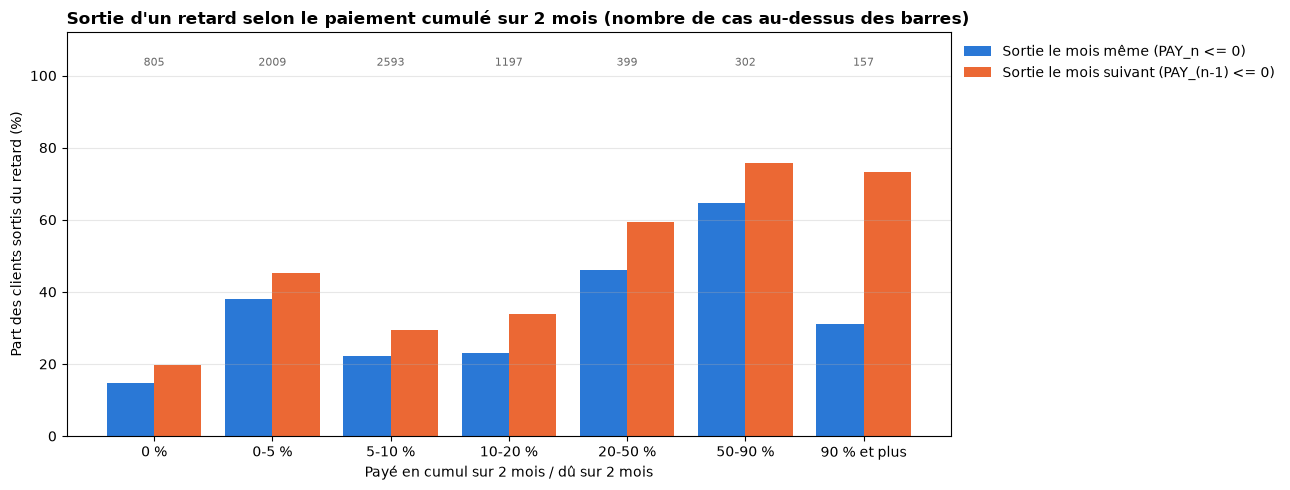

,Nb de cas,Sortie le mois même : PAY_n <= 0 (%),Sortie le mois suivant : PAY_(n-1) <= 0 (%)
Payé en cumul sur 2 mois / dû,,,
0 %,805,14.8,19.6
0-5 %,2009,37.9,45.2
5-10 %,2593,22.3,29.5
10-20 %,1197,23.1,33.8
20-50 %,399,46.1,59.4
50-90 %,302,64.6,75.8
90 % et plus,157,31.2,73.2


In [109]:
# Sortie d'un retard selon le payé en cumul sur 2 mois, lue le mois même (PAY_n) et le mois suivant (PAY_(n-1)) (train, sans dpnm)
lignes = []
for n in range(2, 5):
    ok = (df_train[f'PAY_{n+1}'] >= 2) & (df_train[f'BILL_AMT{n+2}'] > 0)
    paye = df_train[f'PAY_AMT{n+1}'] + df_train[f'PAY_AMT{n}']
    du = df_train[f'BILL_AMT{n+1}'] + df_train[f'PAY_AMT{n+1}']
    lignes.append(pd.DataFrame({
        'PAY_n': df_train.loc[ok, f'PAY_{n}'],
        'PAY_(n-1)': df_train.loc[ok, f'PAY_{n-1}'],
        'Ratio cumulé': (paye / du.where(du > 0) * 100).fillna(100)[ok],   # rien dû sur la période : considéré soldé
    }))
sortie_52 = pd.concat(lignes, ignore_index=True)
sortie_52 = sortie_52[(sortie_52['PAY_n'] != 1) & (sortie_52['PAY_(n-1)'] != 1)]

tranches = ['0 %', '0-5 %', '5-10 %', '10-20 %', '20-50 %', '50-90 %', '90 % et plus']
r = sortie_52['Ratio cumulé']
sortie_52['Tranche'] = pd.Categorical(np.select([r <= 0, r < 5, r < 10, r < 20, r < 50, r < 90], tranches[:6], default=tranches[6]),
                                      categories=tranches)
resume_52 = pd.DataFrame({
    'Nb de cas': sortie_52.groupby('Tranche', observed=False).size(),
    'Sortie le mois même : PAY_n <= 0 (%)': (sortie_52['PAY_n'] <= 0).groupby(sortie_52['Tranche'], observed=False).mean() * 100,
    'Sortie le mois suivant : PAY_(n-1) <= 0 (%)': (sortie_52['PAY_(n-1)'] <= 0).groupby(sortie_52['Tranche'], observed=False).mean() * 100,
}).round(1)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(tranches))
ax.bar(x - 0.2, resume_52['Sortie le mois même : PAY_n <= 0 (%)'], width=0.4, color='#2a78d6', label='Sortie le mois même (PAY_n <= 0)')
ax.bar(x + 0.2, resume_52['Sortie le mois suivant : PAY_(n-1) <= 0 (%)'], width=0.4, color='#eb6834',
       label='Sortie le mois suivant (PAY_(n-1) <= 0)')
for xi, nb in zip(x, resume_52['Nb de cas']):
    ax.text(xi, 102, f'{nb}', ha='center', va='bottom', fontsize=8, color='dimgrey')
ax.set_xticks(x)
ax.set_xticklabels(tranches)
ax.set_ylim(0, 112)
ax.set_xlabel('Payé en cumul sur 2 mois / dû sur 2 mois')
ax.set_ylabel('Part des clients sortis du retard (%)')
ax.set_title("Sortie d'un retard selon le paiement cumulé sur 2 mois (nombre de cas au-dessus des barres)", fontweight='bold', loc='left')
ax.legend(frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
display(resume_52.rename_axis('Payé en cumul sur 2 mois / dû'))

**Interprétation**
- **La sortie du retard se lit surtout le mois suivant** : à paiement égal, elle est plus fréquente dans PAY_(n-1) que dans PAY_n. La codification est mise à jour avec un mois de décalage sur le paiement ; un paiement fait en M-1 ne peut donc se voir que dans la codification de M, qui n'est pas observée. L'écart est le plus net pour les clients qui ont réglé leur dette : la plupart restent codés en retard le mois même et n'en sortent que le mois suivant.
- **Ne rien payer sur 2 mois mène rarement à une sortie** ; payer une part importante de sa dette mène à une sortie dans la majorité des cas. Entre les deux, la sortie augmente **progressivement, sans frontière nette** : aucun seuil de ratio ne se dégage des données. Le seuil de 90 % retenu dans les règles repose sur la logique métier (dette soldée), pas sur une rupture observée ici.
- Même avec une dette réglée, une partie des clients reste en retard, et à l'inverse certains sortent sans paiement visible : la sortie dépend aussi d'éléments absents du dataset (arriéré réel, arrangement ou plan de paiement, procédure de recouvrement). Les autres pistes testées dans l'EDA lab (évolution du solde, niveau de la série de retards) n'ont pas fait apparaître d'autre facteur.

**Conclusion sur les PAY_1 = 1** : on ne peut pas transformer davantage les PAY_1 = 1 à partir des données. En dehors des deux cas tranchés par les montants et la logique métier (facture soldée : retour à la codification d'avant le retard ; aucun paiement sur deux factures dues : remise à 2), **PAY_1 = 1 reste un statut d'attente** dont l'issue n'est pas observable. Un modèle de machine learning pourrait en départager une partie en combinant la durée du retard, les paiements et l'évolution du solde (piste d'amélioration).

## 6. Inventaire des corrections de la codification 1 et décisions
Toutes les corrections de la codification 1 envisagées au fil du projet, appliquées ou abandonnées, sont revues ici une par une avec le même critère : **une correction n'est gardée que si la logique métier la justifie** (pas de retard possible sans facture due, facture soldée, etc.) **et si elle ne déplace pas des clients vers ou hors du contentieux sans raison**. `dpnm` (train uniquement) sert seulement à vérifier.

| Correction | Règle | Où | Logique métier |
|---|---|---|---|
| Client 6783 | codifications 1 sur 4 mois remises à 0 | nettoyage niveau 1 | paie correctement chaque mois : codification erronée |
| Facture nulle : codification précédente | PAY_n = 1 et facture exigible nulle (`BILL_AMT(n+1) <= 0`) : PAY_n = PAY_(n+1), en cascade de PAY_5 vers PAY_1 | nettoyage niveau 2 | rien à payer, pas de retard possible : on reprend la codification précédente |
| Facture nulle : 0 | PAY_n = 1 restant avec une facture exigible nulle : PAY_n = 0 | nettoyage niveau 2 | idem, quand la codification précédente est elle-même un 1 posé sur une vraie facture (quelques cas, tous en PAY_1) |
| Facture soldée | PAY_1 = 1, PAY_2 <= 0 et facture de M-1 payée à 90 % ou plus : PAY_1 = PAY_2 | nettoyage niveau 3 | facture soldée : pas de retard |
| Retour à 2 après un retard *(abandonnée)* | PAY_1 = PAY_2 si PAY_2 >= 2 (ancien niveau 3, avec des seuils de 4 % et 10 %) | ancien niveau 3 | un 1 après un retard serait la suite du retard |
| Mois de transition | PAY_2 >= 2 et PAY_1 <= 1 : remis à 2 si aucun paiement en M-1 ni en M-2 alors que deux factures étaient dues ; facture de M-1 soldée (90 % ou plus) : retour à la codification d'avant le retard ; sinon PAY_1 inchangé (recodage révisé : l'ancien recodage en -1 dès 10 % de paiement est supprimé) | contentieux (`recodage_pay1`, section 6.1 de `05_02_EDA_contentieux`), pas dans le nettoyage | un changement de codification doit être confirmé par les montants |

In [110]:
# Nombre de cas concernés par chaque correction et effet sur le contentieux
c1 = niveaux['cleaned1']
c2 = niveaux['cleaned2']
c3 = niveaux['cleaned3']

# Facture nulle : PAY_n = 1 posés sur une facture exigible nulle (données du niveau 1, avant correction)
cas_c2_c3 = sum(((c1[f'PAY_{k}'] == 1) & (c1[f'BILL_AMT{k+1}'] <= 0)).sum() for k in range(1, 6))
# Facture soldée : PAY_1 = 1 après une codification saine, facture de M-1 payée à 90 % ou plus (données du niveau 2)
ratio_c2 = c2['PAY_AMT1'] / c2['BILL_AMT2'].where(c2['BILL_AMT2'] > 0) * 100
un_sain_c2 = (c2['PAY_1'] == 1) & (c2['PAY_2'] <= 0)
print(f"Facture nulle : {cas_c2_c3} valeurs PAY_n = 1 avec une facture exigible BILL_AMT(n+1) <= 0 (n = 1 à 5, niveau 1), corrigées au niveau 2")
print(f"Facture soldée : {un_sain_c2.sum()} clients avec PAY_1 = 1 et PAY_2 <= 0 au niveau 2, dont {(un_sain_c2 & (ratio_c2 >= 90)).sum()} "
      f"avec PAY_AMT1 >= 90 % de BILL_AMT2 (corrigés au niveau 3) et {(un_sain_c2 & (ratio_c2 < 90)).sum()} en dessous (conservés)")

# Aucune de ces corrections ne crée de PAY_n >= 2 (elles ne peuvent donc pas faire entrer un client au CTX)
print("Nombre de valeurs PAY_n >= 2 (PAY_1 à PAY_6, toutes lignes) : "
      + " | ".join(f"{nom} {int((d[pay_cols] >= 2).sum().sum())}" for nom, d in niveaux.items() if nom != 'brut'))

# Retour à 2 après un retard (abandonné) : simulation sur le train
train_v1 = df_train.copy()
m = (train_v1['PAY_1'] == 1) & (train_v1['PAY_2'] >= 2)
train_v1.loc[m, 'PAY_1'] = train_v1.loc[m, 'PAY_2']
statuts_v1 = statut_ctx_regle2(train_v1)
ctx_actuel = statuts_train['STATUT_CTX'] == 'CTX'
ctx_v1 = statuts_v1['STATUT_CTX'] == 'CTX'
print(f"\nRetour à 2 après un retard, simulé sur le train (PAY_1 = 1 et PAY_2 >= 2 : PAY_1 remplacé par PAY_2) : clients au CTX à M (STATUT_CTX) "
      f"{ctx_actuel.sum()} -> {ctx_v1.sum()}, dont {(ctx_v1 & ~ctx_actuel).sum()} ajoutés")
display(pd.DataFrame({
    'CTX actuel': [ctx_actuel.sum(), df_train.loc[ctx_actuel, 'dpnm'].mean() * 100],
    'CTX avec le retour à 2': [ctx_v1.sum(), df_train.loc[ctx_v1, 'dpnm'].mean() * 100],
    'Ajoutés par le retour à 2': [(ctx_v1 & ~ctx_actuel).sum(), df_train.loc[ctx_v1 & ~ctx_actuel, 'dpnm'].mean() * 100],
}, index=['Nb clients', 'Taux de défaut (%)']).round(1))


Facture nulle : 597 valeurs PAY_n = 1 avec une facture exigible BILL_AMT(n+1) <= 0 (n = 1 à 5, niveau 1), corrigées au niveau 2
Facture soldée : 682 clients avec PAY_1 = 1 et PAY_2 <= 0 au niveau 2, dont 670 avec PAY_AMT1 >= 90 % de BILL_AMT2 (corrigés au niveau 3) et 12 en dessous (conservés)
Nombre de valeurs PAY_n >= 2 (PAY_1 à PAY_6, toutes lignes) : cleaned1 21304 | cleaned2 21304 | cleaned3 21304

Retour à 2 après un retard, simulé sur le train (PAY_1 = 1 et PAY_2 >= 2 : PAY_1 remplacé par PAY_2) : clients au CTX à M (STATUT_CTX) 2403 -> 3752, dont 1349 ajoutés


,CTX actuel,CTX avec le retour à 2,Ajoutés par le retour à 2
Nb clients,2403.0,3752.0,1349.0
Taux de défaut (%),70.3,60.2,42.3


**Décisions**

| Correction | Décision | Justification |
|---|---|---|
| Client 6783 | **Garder** | cas isolé, erreur évidente |
| Facture nulle (codification précédente, puis 0) | **Garder** | pas de retard possible sans facture due ; ces corrections ne créent aucun PAY_n >= 2 et ne touchent donc pas au CTX. La mise à 0 ne traite que quelques cas où la cascade recopie un 1, mais reste justifiée |
| Facture soldée | **Garder** | les « 1 après une codification saine » avec une facture due l'ont presque tous soldée : la codification 1 n'y est pas un retard. Le seuil de 90 % correspond au paiement total (marche nette à 100 % entre les codifications 0 et -1, voir l'EDA lab) |
| Retour à 2 après un retard | **Abandon confirmé** | il ferait entrer au CTX un grand nombre de clients dont le risque est celui des clients sortis (section 5), et diluerait fortement le CTX |
| Mois de transition | **Garder dans le contentieux**, pas dans le nettoyage, avec le recodage révisé | le « 1 après retard » est un statut d'attente (sections 1, 3 et 5.2) : seuls les montants (aucun paiement sur deux factures dues, ou facture soldée) permettent de trancher ; aucune autre règle ne ressort des données |
| — | **Ne plus chercher d'autre correction de la codification 1** | les « 1 après retard » laissés à 1 ont le risque des clients sortis ; ce qui les distingue, c'est la durée du retard précédent : traitée comme une feature (`NB_MOIS_CTX`, section 5.1), pas comme une correction |

Conséquence : le nettoyage (niveaux 1 à 3) reste tel quel. Seul le recodage du mois de transition a été révisé dans `05_02_EDA_contentieux` (section 6.1), sans effet sur la population contentieuse.

**Révision du 03/10/2026** : le mois de transition est finalement recodé **dans le nettoyage** (niveau 5, `cleaned5`), avec la même règle : les corrections de codification issues du contentieux sont appliquées avant l'analyse exploratoire, sans retirer de client. Les décisions ci-dessus sur la codification 1 (niveaux 1 à 3) restent valables.

## 7. Contrôle de `cleaned5` (niveau 5 du nettoyage)
Le niveau 5 de `02_01_nettoyage` applique les corrections de codification issues de l'étude du contentieux (`05_02_EDA_contentieux`, définition 2) **directement dans les `PAY_n`**, et ajoute les colonnes du contentieux (`FAUX_CODAGE`, `SURVEILLANCE_RECENTE`, `FLAG_CTX`, `MOIS_SORTIE_CTX`, `FLAG_RETARD`, `MOIS_SORTIE_RETARD`, `NB_MOIS_CTX` ; définitions dans `docs/colonnes_creees.md`). Aucun client n'est retiré. L'une de ces corrections tranche des codifications 1 : c'est pourquoi le contrôle se fait ici.

**À quoi servent ces vérifications ?** Le niveau 5 modifie automatiquement les codifications de 28 851 clients. Un programme qui modifie des données peut se tromper de trois façons, et chaque sous-partie vérifie l'une d'elles :
1. **oublier des cas** : une correction qui ne s'applique pas partout où elle devrait (7.1) ;
2. **créer des erreurs** : une codification modifiée sans raison, ou qui contredit les règles (7.2) ;
3. **déformer la population** : des clients envoyés à tort au contentieux, ou des codifications 1 tranchées dans le mauvais sens (7.3).

**Ce que fait le niveau 5, et où on le vérifie**

| Correction du niveau 5 | En clair | Vérifiée en |
|---|---|---|
| Faux retards neutralisés | une codification de retard posée alors qu'aucune facture n'était due est remplacée par la codification saine qui la précède | 7.1 et 7.2 |
| Mois de transition recodé | un client en retard en août et codifié 1 (ou sain) en septembre est remis à 2 s'il n'a rien payé ni en août ni en septembre alors que deux factures étaient dues ; il revient à sa codification d'avant le retard s'il a soldé sa facture ; sinon, il reste tel quel | 7.1, 7.2 et 7.3 |
| Colonnes du contentieux | les indicateurs de la définition 2 (passage au contentieux, sortie, retard isolé régularisé, durée du dernier passage) | 7.2 et 7.3 |

*Données : `cleaned4` (avant les corrections) et `cleaned5` (après), mêmes lignes ; pour la validation avec `dpnm` (7.3), périmètre S12 et **mêmes clients de train** que les sections 4 à 6.*

In [111]:
# Données du contrôle : cleaned4 (avant les corrections de codification) et cleaned5 (après), mêmes lignes
df_c4 = pd.read_csv(root_dir / "data" / "cleaned4_creditcard.csv")
df_c5 = pd.read_csv(root_dir / "data" / "cleaned5_creditcard.csv")
assert (df_c4['ID'].values == df_c5['ID'].values).all(), "cleaned4 et cleaned5 doivent avoir les mêmes lignes"

# Mêmes clients de train que les sections 4 à 6 (le split a été fait sur cleaned3, périmètre S12)
c4_id, c5_id = df_c4.set_index('ID'), df_c5.set_index('ID')
assert df_train['ID'].isin(c5_id.index).all()
train4 = c4_id.loc[df_train['ID']].set_index(df_train.index)
train5 = c5_id.loc[df_train['ID']].set_index(df_train.index)

# Ce que la règle du contentieux (copies de 05_02, section 0) produit à partir de cleaned4 : la référence attendue
attendu4, faux_codage4, surveillance4 = corriger_faux_codage(df_c4, neutraliser_endormis=True)
attendu4['PAY_1'] = recodage_pay1(attendu4)
statuts_c4 = statut_ctx_regle2(df_c4)
print(f"cleaned4 et cleaned5 : {len(df_c5)} clients | train relu dans cleaned5 : {len(train5)} clients")

cleaned4 et cleaned5 : 28851 clients | train relu dans cleaned5 : 21761 clients


### 7.1 Les corrections ont-elles été appliquées partout ?
On compte, avant (`cleaned4`) et après (`cleaned5`), les cas que chaque règle doit corriger. Après le niveau 5, il ne doit en rester **aucun**. Dernière ligne : on applique les règles une seconde fois sur `cleaned5` ; si tout a été corrigé du premier coup, elles ne trouvent plus rien à changer.

*Comment lire* : une ligne par règle ; la colonne de droite doit valoir 0.

In [112]:
def cas_a_corriger(d):
    # Faux retards : entrées en retard (PAY_m >= 2 après PAY_(m+1) < 2) alors que la facture BILL_AMT(m+1) était nulle
    entrees_facture_nulle = sum(int(((d[f'PAY_{m}'] >= 2) & (d[f'PAY_{m+1}'] < 2) & (d[f'BILL_AMT{m+1}'] <= 0)).sum()) for m in range(1, 6))
    # Mois de transition : ce que recodage_pay1 changerait encore, après neutralisation des faux retards
    corrige, _, _ = corriger_faux_codage(d, neutraliser_endormis=True)
    recode = recodage_pay1(corrige)
    change = recode != corrige['PAY_1']
    return pd.Series({
        "Retard posé alors qu'aucune facture n'était due (faux retard à neutraliser)": entrees_facture_nulle,
        "Mois de transition sans aucun paiement sur deux factures dues, pas encore remis à 2": int((change & (recode == 2)).sum()),
        "Mois de transition avec facture soldée, pas encore revenu à la codification d'avant le retard": int((change & (recode <= 0)).sum()),
    })

controle_71 = pd.DataFrame({'Cas à corriger dans cleaned4 (avant)': cas_a_corriger(df_c4),
                            'Cas restants dans cleaned5 (après)': cas_a_corriger(df_c5)})
display(controle_71.rename_axis('Règle'))

seconde, _, _ = corriger_faux_codage(df_c5, neutraliser_endormis=True)
seconde['PAY_1'] = recodage_pay1(seconde)
print(f"Seconde application des règles sur cleaned5 : {int((seconde[pay_cols] != df_c5[pay_cols]).sum().sum())} codification(s) modifiée(s)")

,Cas à corriger dans cleaned4 (avant),Cas restants dans cleaned5 (après)
Règle,,
Retard posé alors qu'aucune facture n'était due (faux retard à neutraliser),224,0
"Mois de transition sans aucun paiement sur deux factures dues, pas encore remis à 2",118,0
"Mois de transition avec facture soldée, pas encore revenu à la codification d'avant le retard",5,0


Seconde application des règles sur cleaned5 : 0 codification(s) modifiée(s)


**Réponse : oui.** Tous les cas à corriger dans `cleaned4` sont corrigés dans `cleaned5`, et une seconde application des règles ne change plus aucune codification : aucun cas n'a été oublié.

### 7.2 Les corrections ont-elles créé des erreurs ?
Deux vérifications :
1. **chaque codification modifiée s'explique par une règle** : on liste toutes les différences entre `cleaned4` et `cleaned5`, par type de modification (codification avant → après), avec la règle qui la produit. Aucune modification ne doit rester sans explication ;
2. **les colonnes ajoutées sont exactement celles de la règle du contentieux** : on les compare à `statut_ctx_regle2` (section 0, copie de `05_02_EDA_contentieux`) appliquée à `cleaned4`.

*Comment lire* : premier tableau, la colonne « sans explication » doit valoir 0 ; second tableau, la colonne « écarts » doit valoir 0.

In [113]:
# 1. Toutes les modifications entre cleaned4 et cleaned5, rattachées à la règle qui les produit
etape1, _, _ = corriger_faux_codage(df_c4, neutraliser_endormis=True)      # après neutralisation des faux retards
lignes = []
for col in pay_cols:
    modifie = df_c5[col] != df_c4[col]
    regle = np.where(etape1[col] != df_c4[col], 'faux retard neutralisé',
                     np.where((col == 'PAY_1') & (attendu4['PAY_1'] != etape1['PAY_1']), 'mois de transition recodé', 'sans explication'))
    lignes.append(pd.DataFrame({
        'Modification (avant → après)': df_c4.loc[modifie, col].astype(int).astype(str) + " → " + df_c5.loc[modifie, col].astype(int).astype(str),
        'Règle': regle[modifie.to_numpy()],
    }))
modifs = pd.concat(lignes, ignore_index=True)
tableau_modifs = pd.crosstab(modifs['Modification (avant → après)'], modifs['Règle'], margins=True, margins_name='Total')
if 'sans explication' not in tableau_modifs.columns:
    tableau_modifs.insert(len(tableau_modifs.columns) - 1, 'sans explication', 0)
display(pd.concat([tableau_modifs.drop('Total').sort_values('Total', ascending=False), tableau_modifs.loc[['Total']]]))
clients_modifies = (df_c5[pay_cols] != df_c4[pay_cols]).any(axis=1)
print(f"Clients dont au moins une codification est modifiée : {clients_modifies.sum()} sur {len(df_c5)} ({clients_modifies.mean() * 100:.1f} %)")
print(f"Codifications attendues par la règle mais absentes de cleaned5 : {int((attendu4[pay_cols] != df_c5[pay_cols]).sum().sum())}")

# 2. Colonnes de cleaned5 comparées à la règle du contentieux appliquée à cleaned4
statuts_c4['MOIS_SORTIE_RETARD'] = statuts_c4['MOIS_SORTIE_RETARD'].fillna(-1)   # le niveau 5 met -1 par défaut, jamais vide
comparaison = pd.DataFrame({
    'écarts avec la règle du contentieux': {col: int((df_c5[col].astype(float) != statuts_c4[col].astype(float)).sum())
                                            for col in ['FAUX_CODAGE', 'SURVEILLANCE_RECENTE', 'FLAG_CTX', 'MOIS_SORTIE_CTX', 'FLAG_RETARD', 'MOIS_SORTIE_RETARD']},
    'clients à 1 ou plus dans cleaned5': {col: int((df_c5[col] >= 1).sum())
                                          for col in ['FAUX_CODAGE', 'SURVEILLANCE_RECENTE', 'FLAG_CTX', 'MOIS_SORTIE_CTX', 'FLAG_RETARD', 'MOIS_SORTIE_RETARD']},
})
display(comparaison.rename_axis('Colonne'))

Règle,faux retard neutralisé,mois de transition recodé,sans explication,Total
Modification (avant → après),,,,
2 → -2,442,0,0,442
1 → 2,0,73,0,73
-1 → 2,0,45,0,45
1 → -1,0,2,0,2
-2 → 0,0,1,0,1
-2 → -1,0,1,0,1
-1 → 0,0,1,0,1
2 → 0,1,0,0,1
Total,443,123,0,566


Clients dont au moins une codification est modifiée : 346 sur 28851 (1.2 %)
Codifications attendues par la règle mais absentes de cleaned5 : 0


,écarts avec la règle du contentieux,clients à 1 ou plus dans cleaned5
Colonne,,
FAUX_CODAGE,0,45
SURVEILLANCE_RECENTE,0,179
FLAG_CTX,0,5707
MOIS_SORTIE_CTX,0,2664
FLAG_RETARD,0,2770
MOIS_SORTIE_RETARD,0,2627


**Réponse : non.** Chaque codification modifiée s'explique par l'une des deux règles, aucune modification attendue ne manque, et les colonnes ajoutées sont identiques à celles de la règle du contentieux. Les modifications les plus nombreuses neutralisent des faux retards (retard ramené à la codification saine qui le précède) ; le recodage du mois de transition, lui, touche peu de clients. Les retards qui restent sur une facture nulle dans `cleaned5` ne sont pas des erreurs : ils prolongent une série commencée sur une facture due (la règle ne neutralise que les **entrées** en retard sur une facture nulle).

### 7.3 Les corrections ont-elles déformé la population ?
Trois vérifications :
1. **ce que deviennent les codifications 1** : combien sont tranchées (remises à 2, ou revenues à la codification d'avant le retard), combien restent indécidables ;
2. **la population contentieuse est celle de la règle étudiée** : même nombre de clients au contentieux à M ;
3. **les codifications 1 laissées telles quelles ont bien le risque de clients sortis du retard** (`dpnm`, **train uniquement**, pour vérifier et non pour fixer une règle). On compare leur taux de défaut à deux groupes **témoins**, eux aussi en retard en août mais dont l'issue est claire : ceux restés en retard en septembre (au contentieux à M), et ceux revenus à une codification saine en septembre (vraiment sortis du retard).

*Comment lire le dernier tableau* : les clients « laissés à 1 » doivent avoir un taux de défaut proche du témoin « sorti du retard », et loin du témoin « resté en retard ».

In [114]:
# 1. Devenir des PAY_1 = 1 de cleaned4 dans cleaned5 (toutes lignes)
un_c4 = df_c4['PAY_1'] == 1
devenir = pd.Series(np.select([df_c5['PAY_1'] >= 2, df_c5['PAY_1'] <= 0], ['remis à 2 (au contentieux)', "revenu à la codification d'avant le retard (facture soldée)"],
                              default='laissé à 1 (indécidable)'), index=df_c5.index)
display(devenir[un_c4].value_counts().rename('Nombre de PAY_1 = 1').rename_axis('Dans cleaned5').to_frame())
nb_brut, nb_restants = int((df_brut['PAY_1'] == 1).sum()), int((df_c5['PAY_1'] == 1).sum())
print(f"PAY_1 = 1 : {nb_brut} dans les données brutes, {int(un_c4.sum())} dans cleaned4, {nb_restants} dans cleaned5 : "
      f"{nb_restants / nb_brut * 100:.1f} % des codifications 1 d'origine restent indécidables")

# 2. Population contentieuse : clients au contentieux à M (FLAG_CTX = 1 et MOIS_SORTIE_CTX = -1)
au_ctx_m = (df_c5['FLAG_CTX'] == 1) & (df_c5['MOIS_SORTIE_CTX'] == -1)
print(f"\nClients au contentieux à M : {au_ctx_m.sum()} dans cleaned5 | {(statuts_c4['STATUT_CTX'] == 'CTX').sum()} selon la règle du contentieux")
sortis = (train5['FLAG_CTX'] == 1) & train5['MOIS_SORTIE_CTX'].between(1, 5)
print(f"Durée du dernier passage au contentieux (NB_MOIS_CTX) : {int((train5.loc[nb_mois_ctx.index, 'NB_MOIS_CTX'] != nb_mois_ctx).sum())} écart "
      f"avec le calcul de la section 5.1 ({len(nb_mois_ctx)} clients sortis du contentieux)")

# 3. Taux de défaut des codifications 1 tranchées ou non, face aux deux témoins (train)
apres_retard = (train4['PAY_1'] == 1) & (train4['PAY_2'] >= 2)
groupe = pd.Series(np.select(
    [apres_retard & (train5['PAY_1'] == 1), apres_retard & (train5['PAY_1'] >= 2), apres_retard & (train5['PAY_1'] <= 0),
     (train4['PAY_1'] <= 0) & (train4['PAY_2'] >= 2),
     (train4['PAY_1'] >= 2) & (train4['PAY_2'] >= 2) & (train5['FLAG_CTX'] == 1) & (train5['MOIS_SORTIE_CTX'] == -1)],
    ['Codifié 1 après un retard, laissé à 1', 'Codifié 1 après un retard, remis à 2',
     "Codifié 1 après un retard, facture soldée",
     'Témoin : sorti du retard en septembre (codification saine)', 'Témoin : resté en retard en septembre (au contentieux à M)'],
    default='autre'), index=train5.index)
ordre = ['Témoin : sorti du retard en septembre (codification saine)', 'Codifié 1 après un retard, laissé à 1',
         'Codifié 1 après un retard, remis à 2', "Codifié 1 après un retard, facture soldée",
         'Témoin : resté en retard en septembre (au contentieux à M)']
validation = (train5.groupby(groupe)['dpnm'].agg(clients='size', taux='mean').reindex(ordre)
              .assign(taux=lambda t: (t['taux'] * 100).round(1)).rename(columns={'clients': 'Clients (train)', 'taux': 'Taux de défaut (%)'}))
print("\nTous ces clients étaient en retard en août (PAY_2 >= 2) ; ce qui les distingue, c'est leur codification de septembre :")
display(validation.rename_axis('Groupe'))

,Nombre de PAY_1 = 1
Dans cleaned5,
laissé à 1 (indécidable),1761
remis à 2 (au contentieux),73
revenu à la codification d'avant le retard (facture soldée),2


PAY_1 = 1 : 3688 dans les données brutes, 1836 dans cleaned4, 1761 dans cleaned5 : 47.7 % des codifications 1 d'origine restent indécidables

Clients au contentieux à M : 3004 dans cleaned5 | 3004 selon la règle du contentieux
Durée du dernier passage au contentieux (NB_MOIS_CTX) : 0 écart avec le calcul de la section 5.1 (2086 clients sortis du contentieux)

Tous ces clients étaient en retard en août (PAY_2 >= 2) ; ce qui les distingue, c'est leur codification de septembre :


,Clients (train),Taux de défaut (%)
Groupe,,
Témoin : sorti du retard en septembre (codification saine),361,37.7
"Codifié 1 après un retard, laissé à 1",1411,41.6
"Codifié 1 après un retard, remis à 2",62,50.0
"Codifié 1 après un retard, facture soldée",1,100.0
Témoin : resté en retard en septembre (au contentieux à M),1640,72.1


**Réponse : non.**
- **Peu de codifications 1 sont tranchées** : le niveau 5 en remet une petite minorité à 2 (aucun paiement sur deux factures dues) et en ramène quelques-unes à leur codification d'avant le retard (facture soldée). Près de la moitié des codifications 1 d'origine restent **indécidables** : seuls les montants permettent de trancher, et ils le font rarement.
- **La population contentieuse est exactement celle de la règle étudiée** : même nombre de clients au contentieux à M, même durée du dernier passage au contentieux.
- **Les codifications 1 laissées telles quelles ont le risque de clients sortis du retard** : leur taux de défaut est proche de celui du témoin « sorti du retard », et loin de celui du témoin « resté en retard ». Les traiter comme sortis du contentieux, ce que fait la règle, est cohérent ; les envoyer au contentieux aurait gonflé cette population avec des clients bien moins risqués. Les clients remis à 2 se situent entre les deux témoins. Le groupe « facture soldée » ne compte qu'un client : son taux n'a pas de sens.
- **Les corrections touchent une minorité de clients** (un peu plus de 1 % des clients ont au moins une codification modifiée, voir 7.2) : leur effet sur les taux de défaut d'ensemble est imperceptible. Leur intérêt est ailleurs : rendre les codifications cohérentes avec les montants, pour que les clients concernés soient bien classés (contentieux, sortie, retard isolé) et que l'analyse des retards ne soit pas faussée par des retards fictifs.
- **Les « 1 après 1 » ne sont pas corrigés** (6 clients, section 2) : ce ne sont pas des mois de transition (`PAY_2` vaut déjà 1), et aucun ne remplit les conditions de la règle (ni double absence de paiement, ni facture soldée en septembre). Une règle écrite pour 6 clients serait faite sur mesure.

**Conclusion du contrôle** : `cleaned5` applique toutes les corrections, sans en oublier, sans créer d'erreur et sans déformer la population. Il peut servir de base à l'analyse exploratoire et au ML.

## 8. Conclusion
- **La codification 1 est un statut provisoire du dernier mois.** Elle n'existe presque qu'en M-1 et prend la place, dans l'attente, de sorties comme de retards maintenus que l'historique tranche ensuite. Elle n'est pas un « retard d'un mois » au sens de la documentation du dataset.
- **Deux familles de codifications 1** :
  - après une codification saine : une alerte ou un statut posé sur un compte sans dette ou dont la facture est soldée ; le nettoyage les corrige (niveaux 2 et 3), et elles se comportent ensuite comme des clients sains ;
  - après un retard : un statut d'attente, avec une dette toujours due et des paiements partiels, dont l'issue n'est pas encore visible.
- **La codification est mise à jour avec un mois de décalage sur les paiements** : la sortie d'un retard se lit le mois suivant le paiement. C'est ce qui justifie de regarder 2 mois de paiement dans les règles du contentieux.
- **Aucune règle autre que la règle métier du paiement (dette réglée à 90 % ou plus) ne permet d'anticiper une sortie de retard.** Le recodage du mois de transition a été révisé en conséquence dans `05_02_EDA_contentieux` (facture soldée : retour à la codification d'avant le retard ; branche des 10 % supprimée), sans changer la population contentieuse.
- **Le nettoyage de la codification 1 (niveaux 1 à 3) reste tel quel** (section 6). Le recodage du mois de transition et la neutralisation des faux retards sont appliqués au **niveau 5** (`cleaned5`), contrôlé en section 7 : `cleaned5` reproduit exactement la règle du contentieux, sans effet de bord ; 47,7 % des codifications 1 d'origine restent indécidables.
- **Nouvelles features**, définies dans `docs/colonnes_creees.md` : `NB_MOIS_CTX` (durée du dernier passage au CTX, section 5.1, créée au niveau 5) et `CUMUL_INCIDENT` (nombre total de mois à >= 2, simple comptage créé dans `05_03_EDA_storytelling`), à tester dans le ML.

**Pistes d'amélioration**
- Un modèle de machine learning pourrait départager une partie des PAY_1 = 1 après un retard (sortie réelle ou retard toujours en cours), en combinant la durée du retard, les paiements et l'évolution du solde.
- Les codifications 1 posées sur un encours nul sont à relier à l'étude des comptes inactifs.

---
## Annexe : analyses exploratoires reprises de l'EDA lab (archive)
Cellules déplacées depuis `05_01_EDA_lab`, **conservées telles quelles et dans leur ordre d'origine** : c'est l'historique exploratoire qui a conduit à cette étude, avec ses essais, ses tâtonnements et des pistes abandonnées depuis (par exemple remettre les PAY_1 = 1 à 2). **Les conclusions à retenir sont celles des sections 1 à 7.** Les analyses sur l'évolution du risque mois par mois sont restées dans l'EDA lab (« Analyse du risque et de son évolution »).

Données : **données brutes** (30 000 lignes moins les 4 paiements supérieurs à 1 000 000 NT$, comptes inactifs inclus), comme dans le lab. Les sorties sont recalculées dans ce notebook, dans le même contexte que le lab.

⚠️ Certaines cellules **modifient `df`** (client 6783, simulation des corrections de niveau 2) : l'annexe doit être exécutée à la suite, après la cellule de préparation ci-dessous.

⚠️ Comme dans le lab, certaines cellules calculent des taux de défaut (`dpnm`) sur **toutes les lignes**, y compris celles du futur test : ce sont des analyses exploratoires antérieures au split, à titre d'information. Aucune règle ni décision de ce notebook ne s'appuie dessus.

In [115]:
# Préparation de l'annexe : même contexte que l'EDA lab
df = pd.read_csv(root_dir / "data" / "creditcard_pret_ingestion.csv")
df_initial = df.copy()
df = df.set_index('ID')

# Suppression des 4 paiements supérieurs à 1 000 000 NT$ (comme dans le lab et le nettoyage)
df = df[~(df[pay_amt_cols] > 1_000_000).any(axis=1)].copy()

# Colonnes créées : définitions uniques (docs/colonnes_creees.md)
for n in range(1, 6):
    bill = df[f'BILL_AMT{n+1}']
    df[f'ratio_PAY_BILL{n}'] = (df[f'PAY_AMT{n}'] / bill.where(bill > 0) * 100).clip(lower=0, upper=200).fillna(100)
df['ratio_PAY_to_BILL_median'] = df[[f'ratio_PAY_BILL{n}' for n in range(1, 6)]].median(axis=1)
print(f"Annexe : {len(df)} lignes")


Annexe : 29996 lignes


In [116]:
mask=(df['PAY_1'] == 1) & (df['PAY_AMT1']<=0) & (df['BILL_AMT1']<=0)
nb_pay1_nopayment = df['PAY_1'].loc[mask].count()
print(f"Lignes PAY_1=1 sans paiement et sans encours : {nb_pay1_nopayment}")
mask=(df['PAY_1'] == 1) & (df['PAY_AMT1']<=0) & (df['BILL_AMT1']>0)
nb_pay1_nopayment = df['PAY_1'].loc[mask].count()
print(f"Lignes PAY_1=1 sans paiement et avec encours : {nb_pay1_nopayment}")

Lignes PAY_1=1 sans paiement et sans encours : 1118
Lignes PAY_1=1 sans paiement et avec encours : 1072


la valeur '1' dans PAY_n est clairement sous représentée  
quelques exemples dans le dataset au dessus montre qu'un dossier sain passe en incident directement à 2  
2 dossiers sains sans encours passent également au statut 'incident 1', ce qui semble être une réelle anomalie

In [117]:
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
mask = (df[pay_columns] == 1).any(axis=1)
df[mask].head(20)

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm,ratio_PAY_BILL1,ratio_PAY_BILL2,ratio_PAY_BILL3,ratio_PAY_BILL4,ratio_PAY_BILL5,ratio_PAY_to_BILL_median
ID,,,,,,,,,,,,,,,,,,,,,
14,70000,1,2,2,30,1,2,2,0,0,...,3000,1500,0,1,4.749959,0.000000,4.492228,8.301741,4.065702,4.492228
16,50000,2,3,3,23,1,2,0,0,0,...,1200,1300,1100,0,0.000000,5.335041,3.823294,4.063526,4.303068,4.063526
19,360000,2,1,1,49,1,-2,-2,-2,-2,...,0,0,0,0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
20,180000,2,1,2,29,1,-2,-2,-2,-2,...,0,0,0,0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
27,60000,1,1,2,27,1,-2,-1,-1,-1,...,500,0,1000,1,100.000000,200.000000,100.000000,200.000000,100.000000,100.000000
39,50000,1,1,2,25,1,-1,-1,-2,-2,...,0,0,0,1,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
51,70000,1,3,2,42,1,2,2,2,2,...,0,1500,1500,1,0.000000,8.082388,5.073181,0.000000,3.810782,3.810782
54,180000,2,1,2,25,1,2,0,0,0,...,1762,1790,1622,0,3.114369,4.700875,4.049644,3.966682,3.949778,3.966682
69,130000,2,3,2,29,1,-2,-2,-1,2,...,0,7319,13899,0,100.000000,100.000000,195.529047,0.000000,100.000000,100.000000


In [118]:
pay_columns = ['PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
mask = (df[pay_columns] == 1).any(axis=1)
df[mask]

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT4,PAY_AMT5,PAY_AMT6,dpnm,ratio_PAY_BILL1,ratio_PAY_BILL2,ratio_PAY_BILL3,ratio_PAY_BILL4,ratio_PAY_BILL5,ratio_PAY_to_BILL_median
ID,,,,,,,,,,,,,,,,,,,,,
892,400000,1,2,2,37,1,1,1,2,0,...,7040,2006,2005,0,20.038497,31.570331,0.023811,37.851497,16.330186,20.038497
1967,90000,1,2,1,29,1,1,1,0,0,...,48012,1756,1894,0,7.129715,1.352082,31.531532,99.893889,3.644212,7.129715
5645,500000,1,1,1,42,1,1,0,0,0,...,5666,4825,100225,0,10.544218,99.628111,2.709753,3.561058,3.556738,3.561058
6025,210000,2,2,2,29,1,1,-2,-2,-1,...,4000,3000,5000,0,100.000000,100.000000,100.000000,200.000000,69.013112,100.000000
6118,80000,1,1,2,26,1,1,-2,-2,-2,...,0,0,0,0,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
6783,500000,1,1,1,32,1,1,1,1,0,...,15000,10000,50000,0,37.596105,31.760038,15.637757,23.079764,19.715311,23.079764
8616,270000,2,2,2,53,1,1,-2,-2,-2,...,2,64446,5002,0,100.000000,100.000000,100.000000,100.000000,151.930784,100.000000
9120,50000,1,2,2,40,1,1,-1,-1,0,...,5270,2814,3089,0,100.000000,200.000000,102.923014,17.409977,12.334531,100.000000
11013,20000,2,2,2,45,1,1,-1,0,-1,...,3034,9287,85,0,100.000000,112.774030,12.554653,100.000000,100.000000,100.000000


In [119]:
# Compte le nombre de '1' dans chaque colonne PAY_n
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== COMPTAGE DES VALEURS '1' DANS CHAQUE COLONNE PAY_N ===")

# Compter le nombre de 1 dans chaque colonne
column_counts = {}
total_ones = 0

for col in pay_columns:
    count = (df[col] == 1).sum()
    column_counts[col] = count
    total_ones += count
    percentage = (count / len(df)) * 100
    print(f"{col} : {count} sur {len(df)} ({percentage:.2f}%)")


=== COMPTAGE DES VALEURS '1' DANS CHAQUE COLONNE PAY_N ===
PAY_1 : 3688 sur 29996 (12.29%)
PAY_2 : 28 sur 29996 (0.09%)
PAY_3 : 4 sur 29996 (0.01%)
PAY_4 : 2 sur 29996 (0.01%)
PAY_5 : 0 sur 29996 (0.00%)
PAY_6 : 0 sur 29996 (0.00%)


Je repars sur la codification '1' dans PAY_n pour comprendre la logique et éventuellement envisager un nettoyage.  
Je regarde ce qui précède PAY_n = 1 et ce qui suit PAY_n = 1

In [120]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DE PAY_n+1 QUAND PAY_n = 1 ===")

# Pour chaque colonne PAY_n (sauf la dernière)
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    print(f"\n--- {current_pay} = 1 → {next_pay} ---")
    
    # Créer le masque pour les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        print(f"Nombre de lignes où {current_pay} = 1 : {total_with_current_pay_one}")
        
        # Calculer la répartition des valeurs de PAY_{n+1}
        value_counts = df[mask][next_pay].value_counts().sort_index()
        
        print(f"Répartition de {next_pay} dans ces lignes :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {next_pay} = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
        
        # Afficher quelques statistiques supplémentaires
        next_values = df[mask][next_pay]
        print(f"  - Moyenne de {next_pay} : {next_values.mean():.2f}")
        print(f"  - Médiane de {next_pay} : {next_values.median():.2f}")
        print(f"  - Écart-type de {next_pay} : {next_values.std():.2f}")
        
    else:
        print(f"Aucune ligne où {current_pay} = 1")

print("\n=== ANALYSE COMPARATIVE ===")
print("Comparaison des répartitions entre les différents mois")

# Comparaison des répartitions
for i in range(len(pay_columns) - 1):
    current_pay = pay_columns[i]
    next_pay = pay_columns[i + 1]
    
    # Calculer la proportion de chaque valeur de PAY_{n+1} parmi les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        value_counts = df[mask][next_pay].value_counts().sort_index()
        print(f"\n{current_pay} = 1 → {next_pay} :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {value} : {percentage:.2f}%")

print("\n=== RÉSUMÉ GLOBAL ===")
print("Nombre de lignes avec PAY_n = 1 pour chaque colonne :")

# Afficher le nombre de lignes avec chaque valeur de PAY_n
for pay_col in pay_columns:
    count = (df[pay_col] == 1).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pay_col} = 1 : {count} sur {len(df)} ({percentage:.2f}%)")

=== RÉPARTITION DES VALEURS DE PAY_n+1 QUAND PAY_n = 1 ===

--- PAY_1 = 1 → PAY_2 ---
Nombre de lignes où PAY_1 = 1 : 3688
Répartition de PAY_2 dans ces lignes :
  - PAY_2 = -2 : 1221 sur 3688 (33.11%)
  - PAY_2 = -1 : 612 sur 3688 (16.59%)
  - PAY_2 = 0 : 3 sur 3688 (0.08%)
  - PAY_2 = 1 : 28 sur 3688 (0.76%)
  - PAY_2 = 2 : 1672 sur 3688 (45.34%)
  - PAY_2 = 3 : 109 sur 3688 (2.96%)
  - PAY_2 = 4 : 32 sur 3688 (0.87%)
  - PAY_2 = 5 : 7 sur 3688 (0.19%)
  - PAY_2 = 6 : 2 sur 3688 (0.05%)
  - PAY_2 = 7 : 1 sur 3688 (0.03%)
  - PAY_2 = 8 : 1 sur 3688 (0.03%)
  - Moyenne de PAY_2 : 0.23
  - Médiane de PAY_2 : 1.00
  - Écart-type de PAY_2 : 1.94

--- PAY_2 = 1 → PAY_3 ---
Nombre de lignes où PAY_2 = 1 : 28
Répartition de PAY_3 dans ces lignes :
  - PAY_3 = -2 : 12 sur 28 (42.86%)
  - PAY_3 = -1 : 9 sur 28 (32.14%)
  - PAY_3 = 0 : 1 sur 28 (3.57%)
  - PAY_3 = 1 : 4 sur 28 (14.29%)
  - PAY_3 = 2 : 2 sur 28 (7.14%)
  - Moyenne de PAY_3 : -0.89
  - Médiane de PAY_3 : -1.00
  - Écart-type de P

In [121]:
# Création des listes de colonnes
pay_columns = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print("=== RÉPARTITION DES VALEURS DE PAY_n-1 QUAND PAY_n = 1 ===")

# Pour chaque colonne PAY_n (sauf la première)
for i in range(1, len(pay_columns)):  # Commence à 1 pour pouvoir accéder à PAY_{n-1}
    current_pay = pay_columns[i]
    prev_pay = pay_columns[i - 1]
    
    print(f"\n--- {current_pay} = 1 → {prev_pay} ---")
    
    # Créer le masque pour les lignes où PAY_n = 1
    mask = df[current_pay] == 1
    total_with_current_pay_one = mask.sum()
    
    if total_with_current_pay_one > 0:
        print(f"Nombre de lignes où {current_pay} = 1 : {total_with_current_pay_one}")
        
        # Calculer la répartition des valeurs de PAY_{n-1}
        value_counts = df[mask][prev_pay].value_counts().sort_index()
        
        print(f"Répartition de {prev_pay} dans ces lignes :")
        for value, count in value_counts.items():
            percentage = (count / total_with_current_pay_one) * 100
            print(f"  - {prev_pay} = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
        
        # Afficher quelques statistiques supplémentaires
        prev_values = df[mask][prev_pay]
        print(f"  - Moyenne de {prev_pay} : {prev_values.mean():.2f}")
        print(f"  - Médiane de {prev_pay} : {prev_values.median():.2f}")
        print(f"  - Écart-type de {prev_pay} : {prev_values.std():.2f}")
        
    else:
        print(f"Aucune ligne où {current_pay} = 1")

print("\n=== RÉSUMÉ GLOBAL ===")
print("Nombre de lignes avec PAY_n = 1 pour chaque colonne :")

# Afficher le nombre de lignes avec chaque valeur de PAY_n
for pay_col in pay_columns:
    count = (df[pay_col] == 1).sum()
    percentage = (count / len(df)) * 100
    print(f"  {pay_col} = 1 : {count} sur {len(df)} ({percentage:.2f}%)")



=== RÉPARTITION DES VALEURS DE PAY_n-1 QUAND PAY_n = 1 ===

--- PAY_2 = 1 → PAY_1 ---
Nombre de lignes où PAY_2 = 1 : 28
Répartition de PAY_1 dans ces lignes :
  - PAY_1 = 1 : 28 sur 28 (100.00%)
  - Moyenne de PAY_1 : 1.00
  - Médiane de PAY_1 : 1.00
  - Écart-type de PAY_1 : 0.00

--- PAY_3 = 1 → PAY_2 ---
Nombre de lignes où PAY_3 = 1 : 4
Répartition de PAY_2 dans ces lignes :
  - PAY_2 = 1 : 4 sur 4 (100.00%)
  - Moyenne de PAY_2 : 1.00
  - Médiane de PAY_2 : 1.00
  - Écart-type de PAY_2 : 0.00

--- PAY_4 = 1 → PAY_3 ---
Nombre de lignes où PAY_4 = 1 : 2
Répartition de PAY_3 dans ces lignes :
  - PAY_3 = 1 : 2 sur 2 (100.00%)
  - Moyenne de PAY_3 : 1.00
  - Médiane de PAY_3 : 1.00
  - Écart-type de PAY_3 : 0.00

--- PAY_5 = 1 → PAY_4 ---
Aucune ligne où PAY_5 = 1

--- PAY_6 = 1 → PAY_5 ---
Aucune ligne où PAY_6 = 1

=== RÉSUMÉ GLOBAL ===
Nombre de lignes avec PAY_n = 1 pour chaque colonne :
  PAY_1 = 1 : 3688 sur 29996 (12.29%)
  PAY_2 = 1 : 28 sur 29996 (0.09%)
  PAY_3 = 1 : 4 sur

PAY_n = 1 apparait majoritairement sur des comptes inactifs ou en impayés  
Quand PAY_n =1, PAY_n-1 = 1  
Cela confirme le statut de valeur d'alerte ou pré alerte. Cela peut être aussi un compte en instance de fermeture, de gel...

In [122]:
print("=== TAUX DE dpnm = 1 QUAND PAY_1 = 1 ===")

# Analyse pour PAY_1 = 1
current_pay = 'PAY_1'
mask = df[current_pay] == 1
total_with_current_pay_one = mask.sum()

print(f"Nombre total de lignes où {current_pay} = 1 : {total_with_current_pay_one}")

if total_with_current_pay_one > 0:
    # Calcul du taux de dpnm = 1
    mask_dpnm_one = (df[current_pay] == 1) & (df['dpnm'] == 1)
    count_dpnm_one = mask_dpnm_one.sum()
    
    percentage_dpnm_one = (count_dpnm_one / total_with_current_pay_one) * 100
    
    print(f"Nombre de lignes où {current_pay} = 1 ET dpnm = 1 : {count_dpnm_one}")
    print(f"Taux de dpnm = 1 parmi les lignes où {current_pay} = 1 : {percentage_dpnm_one:.2f}%")
    
    # Répartition complète de dpnm dans ces lignes
    dpnm_distribution = df[mask]['dpnm'].value_counts().sort_index()
    print(f"\nRépartition complète de dpnm pour les lignes où {current_pay} = 1 :")
    for value, count in dpnm_distribution.items():
        percentage = (count / total_with_current_pay_one) * 100
        print(f"  - dpnm = {value} : {count} sur {total_with_current_pay_one} ({percentage:.2f}%)")
    
    # Comparaison avec l'ensemble du dataset
    total_dataset = len(df)
    dpnm_global = df['dpnm'].value_counts().sort_index()
    
    print(f"\n=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===")
    # Calcul des proportions dans les deux cas
    if total_with_current_pay_one > 0:
        print(f"Taux de dpnm = 1 dans les lignes où {current_pay} = 1 : {percentage_dpnm_one:.2f}%")
        print(f"Taux de dpnm = 1 dans l'ensemble du dataset : {(dpnm_global.get(1, 0) / total_dataset * 100):.2f}%")
        
        # Calcul de l'impact
        global_dpnm_1 = (dpnm_global.get(1, 0) / total_dataset) * 100
        if global_dpnm_1 > 0:
            impact = percentage_dpnm_one - global_dpnm_1
            print(f"Écart par rapport à la moyenne : {impact:.2f}%")
       
else:
    print(f"Aucune ligne ne correspond à la condition {current_pay} = 1")

print("\n=== RÉSUMÉ DES RÉPARTITIONS ===")
# Répartition globale des valeurs de PAY_1
pay1_distribution = df['PAY_1'].value_counts().sort_index()
print("Répartition de PAY_1 :")
for value, count in pay1_distribution.items():
    percentage = (count / len(df)) * 100
    print(f"  - PAY_1 = {value} : {count} sur {len(df)} ({percentage:.2f}%)")

=== TAUX DE dpnm = 1 QUAND PAY_1 = 1 ===
Nombre total de lignes où PAY_1 = 1 : 3688
Nombre de lignes où PAY_1 = 1 ET dpnm = 1 : 1252
Taux de dpnm = 1 parmi les lignes où PAY_1 = 1 : 33.95%

Répartition complète de dpnm pour les lignes où PAY_1 = 1 :
  - dpnm = 0 : 2436 sur 3688 (66.05%)
  - dpnm = 1 : 1252 sur 3688 (33.95%)

=== COMPARAISON AVEC L'ENSEMBLE DU DATASET ===
Taux de dpnm = 1 dans les lignes où PAY_1 = 1 : 33.95%
Taux de dpnm = 1 dans l'ensemble du dataset : 22.12%
Écart par rapport à la moyenne : 11.82%

=== RÉSUMÉ DES RÉPARTITIONS ===
Répartition de PAY_1 :
  - PAY_1 = -2 : 2758 sur 29996 (9.19%)
  - PAY_1 = -1 : 5684 sur 29996 (18.95%)
  - PAY_1 = 0 : 14736 sur 29996 (49.13%)
  - PAY_1 = 1 : 3688 sur 29996 (12.29%)
  - PAY_1 = 2 : 2667 sur 29996 (8.89%)
  - PAY_1 = 3 : 322 sur 29996 (1.07%)
  - PAY_1 = 4 : 76 sur 29996 (0.25%)
  - PAY_1 = 5 : 26 sur 29996 (0.09%)
  - PAY_1 = 6 : 11 sur 29996 (0.04%)
  - PAY_1 = 7 : 9 sur 29996 (0.03%)
  - PAY_1 = 8 : 19 sur 29996 (0.06%)

In [123]:

# Compter le nombre de 1 dans la colonne PAY_1
compte_1 = (df['PAY_1'] == 1).sum()

# Calculer le pourcentage
total = len(df)
pourcentage_1 = (compte_1 / total) * 100

print(f"Nombre de 1 dans la colonne PAY_1 : {compte_1}")
print(f"Pourcentage de 1 dans la colonne PAY_1 : {pourcentage_1:.2f}%")


Nombre de 1 dans la colonne PAY_1 : 3688
Pourcentage de 1 dans la colonne PAY_1 : 12.29%


In [124]:
# Définir la condition : PAY_2 = 1 ou PAY_3 = 1 ou PAY_4 = 1
condition = (df['PAY_2'] == 1) | (df['PAY_3'] == 1) | (df['PAY_4'] == 1)

# Récupérer toutes les lignes qui remplissent cette condition
lignes_filtrees = df[condition]

# Afficher le nombre total de lignes correspondantes
print(f"Nombre de lignes où PAY_2 = 1 ou PAY_3 = 1 ou PAY_4 = 1 : {len(lignes_filtrees)}")

# Si tu veux voir plus de colonnes pour mieux comprendre le contexte
print("\nAffichage avec quelques colonnes supplémentaires pour analyse :")
colonnes_affichage = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                     'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5']
print(lignes_filtrees[colonnes_affichage].head(10))

Nombre de lignes où PAY_2 = 1 ou PAY_3 = 1 ou PAY_4 = 1 : 28

Affichage avec quelques colonnes supplémentaires pour analyse :
       PAY_1  PAY_2  PAY_3  PAY_4  PAY_5  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
ID                                                                       
892        1      1      1      2      0      3019      5014         3   
1967       1      1      1      0      0      3100      1000       770   
5645       1      1      0      0      0      1054    177080      4425   
6025       1      1     -2     -2     -1         0         0      2000   
6118       1      1     -2     -2     -2      5000         0         0   
6783       1      1      1      1      0     20000     20012     10036   
8616       1      1     -2     -2     -2         2         2      6002   
9120       1      1     -1     -1      0         0      2931     30000   
11013      1      1     -1      0     -1       700     21400      1005   
11498      1      1      1      1      2     15210      8273

In [125]:
print(df.loc[6783])

LIMIT_BAL                   500000.000000
SEX                              1.000000
EDUCATION                        1.000000
MARRIAGE                         1.000000
AGE                             32.000000
PAY_1                            1.000000
PAY_2                            1.000000
PAY_3                            1.000000
PAY_4                            1.000000
PAY_5                            0.000000
PAY_6                            0.000000
BILL_AMT1                    48169.000000
BILL_AMT2                    53197.000000
BILL_AMT3                    63010.000000
BILL_AMT4                    64178.000000
BILL_AMT5                    64992.000000
BILL_AMT6                    50722.000000
PAY_AMT1                     20000.000000
PAY_AMT2                     20012.000000
PAY_AMT3                     10036.000000
PAY_AMT4                     15000.000000
PAY_AMT5                     10000.000000
PAY_AMT6                     50000.000000
dpnm                             0

Le client ayant le plus de codes 1 est l'ID 6783 qui semble payer tout à fait correctement  
**On peut dire que le client 6783 paie honorablement chaque mois son crédit. La codification 1 est une erreur qu'il faut corriger en 0**

In [126]:
# Vérifier les valeurs actuelles
print("Valeurs avant modification :")
print(df.loc[6783, ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4']])

# Modifier chaque colonne individuellement
df.loc[6783, 'PAY_1'] = 0
df.loc[6783, 'PAY_2'] = 0
df.loc[6783, 'PAY_3'] = 0
df.loc[6783, 'PAY_4'] = 0

# Vérifier les nouvelles valeurs
print("\nValeurs après modification :")
print(df.loc[6783, ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4']])

Valeurs avant modification :
PAY_1    1
PAY_2    1
PAY_3    1
PAY_4    1
Name: 6783, dtype: int64

Valeurs après modification :
PAY_1    0
PAY_2    0
PAY_3    0
PAY_4    0
Name: 6783, dtype: int64


In [127]:
# Définir la condition : PAY_2 = 1 et PAY_3 = 1
condition = (df['PAY_2'] == 1) | (df['PAY_3'] == 1)

# Récupérer toutes les lignes qui remplissent cette condition
lignes_filtrees = df[condition]

# Afficher le nombre total de lignes correspondantes
print(f"Nombre de lignes où PAY_2 = 1 ou PAY_3 = 1 : {len(lignes_filtrees)}")

# Si tu veux voir plus de colonnes pour mieux comprendre le contexte
print("\nAffichage avec quelques colonnes supplémentaires pour analyse :")
colonnes_affichage = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                     'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4']

resultats = lignes_filtrees[colonnes_affichage].head(27)
print(resultats.to_string(float_format='{:,.2f}'.format))

Nombre de lignes où PAY_2 = 1 ou PAY_3 = 1 : 27

Affichage avec quelques colonnes supplémentaires pour analyse :
       PAY_1  PAY_2  PAY_3  PAY_4  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4
ID                                                                                                                   
892        1      1      1      2      3019      5014         3      7040      13611      15066      15882      12599
1967       1      1      1      0      3100      1000       770     48012      41073      43480      73960       2442
5645       1      1      0      0      1054    177080      4425      5666       9615       9996     177741     163299
6025       1      1     -2     -2         0         0      2000      4000       1767      -3355      -3987      -1987
6118       1      1     -2     -2      5000         0         0         0      74384          0          0          0
8616       1      1     -2     -2         2         2      60

In [128]:
# Analyse mois par mois - Répartition complète de tous les PAY_n
print("Analyse mois par mois (Répartition complète de PAY_n avec BILL_AMT(n+1) <= 0) :")
print("=" * 70)

# Pour chaque mois de PAY_1 à PAY_5
for i in range(1, 6):
    col_pay = f'PAY_{i}'
    col_bill = f'BILL_AMT{i+1}'
    
    if col_pay in df.columns and col_bill in df.columns:
        # Condition : BILL_AMT(n+1) <= 0
        condition = df[col_bill] <= 0
        
        # Compter les pourcentages pour toutes les valeurs de PAY_n
        valeurs = df.loc[condition, col_pay].value_counts(normalize=True) * 100
        
        # Compter le nombre total de lignes avec BILL_AMT(n+1) <= 0
        nb_lignes_bill = condition.sum()
        
        print(f"\n{col_pay} avec {col_bill} <= 0 :")
        print(f"  Nombre de lignes avec {col_bill} <= 0 : {nb_lignes_bill}")
        
        # Afficher la répartition complète
        if len(valeurs) > 0:
            for valeur, pourcentage in valeurs.items():
                print(f"  PAY_n = {valeur} : {pourcentage:.2f}%")
        else:
            print("  Aucune valeur trouvée")

# Afficher le nombre total de lignes correspondant à cette condition
print("\n" + "=" * 70)
print("Nombre total d'occurrences par mois :")

for i in range(1, 6):
    col_pay = f'PAY_{i}'
    col_bill = f'BILL_AMT{i+1}'
    
    if col_pay in df.columns and col_bill in df.columns:
        condition = df[col_bill] <= 0
        nb_lignes = condition.sum()
        print(f"{col_pay} avec {col_bill} <= 0 : {nb_lignes} lignes")

Analyse mois par mois (Répartition complète de PAY_n avec BILL_AMT(n+1) <= 0) :

PAY_1 avec BILL_AMT2 <= 0 :
  Nombre de lignes avec BILL_AMT2 <= 0 : 3173
  PAY_n = 1 : 37.03%
  PAY_n = -2 : 29.97%
  PAY_n = -1 : 22.16%
  PAY_n = 0 : 8.86%
  PAY_n = 2 : 1.99%

PAY_2 avec BILL_AMT3 <= 0 :
  Nombre de lignes avec BILL_AMT3 <= 0 : 3525
  PAY_n = -2 : 53.13%
  PAY_n = -1 : 26.10%
  PAY_n = 0 : 15.38%
  PAY_n = 2 : 5.05%
  PAY_n = 1 : 0.34%

PAY_3 avec BILL_AMT4 <= 0 :
  Nombre de lignes avec BILL_AMT4 <= 0 : 3870
  PAY_n = -2 : 58.73%
  PAY_n = -1 : 22.95%
  PAY_n = 0 : 13.90%
  PAY_n = 2 : 4.42%

PAY_4 avec BILL_AMT5 <= 0 :
  Nombre de lignes avec BILL_AMT5 <= 0 : 4161
  PAY_n = -2 : 60.95%
  PAY_n = -1 : 21.29%
  PAY_n = 0 : 15.14%
  PAY_n = 2 : 2.62%

PAY_5 avec BILL_AMT6 <= 0 :
  Nombre de lignes avec BILL_AMT6 <= 0 : 4708
  PAY_n = -2 : 58.84%
  PAY_n = 0 : 19.99%
  PAY_n = -1 : 19.88%
  PAY_n = 2 : 1.30%

Nombre total d'occurrences par mois :
PAY_1 avec BILL_AMT2 <= 0 : 3173 lignes
P

**Interprétation** Peu de comptes toppés en incidents lorsque l'envours est nul ou négatif, ceci est logique niveau métier  
**Correction appropriée des codifications 1 dans ce cas : PAY_n = PAY_(n+1) si BILL_AMT(n+1) <= 0**

In [129]:
# Correction de PAY_n = PAY_(n+1) si (BILL_AMT(n+1) <= 0 et PAY_n = 1)
# En partant de PAY_5 vers PAY_1

nb_corrections = 0

for i in range(5, 0, -1):  # De PAY_5 à PAY_1
    col_pay = f'PAY_{i}'
    col_pay_suivant = f'PAY_{i+1}'
    col_bill = f'BILL_AMT{i+1}'
    
    if col_pay in df.columns and col_pay_suivant in df.columns and col_bill in df.columns:
        # Condition : BILL_AMT(n+1) <= 0 et PAY_n = 1
        condition = (df[col_bill] <= 0) & (df[col_pay] == 1)
        
        # Compter les corrections
        nb_corr = condition.sum()
        nb_corrections += nb_corr
        
        if nb_corr > 0:
            print(f"Correction appliquée sur {nb_corr} lignes : {col_pay} devient {col_pay_suivant}")
            # Appliquer la correction
            df.loc[condition, col_pay] = df.loc[condition, col_pay_suivant]

print(f"Nombre total de corrections appliquées : {nb_corrections}")

Correction appliquée sur 12 lignes : PAY_2 devient PAY_3
Correction appliquée sur 1175 lignes : PAY_1 devient PAY_2
Nombre total de corrections appliquées : 1187


In [130]:
# Compter pour chaque mois PAY_n = 1 avec BILL_AMT(n+1) <= 0
resultats = {}

for i in range(1, 6):  # PAY_1 à PAY_5
    col_pay = f'PAY_{i}'
    col_bill = f'BILL_AMT{i+1}'
    
    if col_pay in df.columns and col_bill in df.columns:
        # Compter les clients avec PAY_n = 1 et BILL_AMT(n+1) <= 0
        condition = (df[col_pay] == 1) & (df[col_bill] <= 0)
        nb_clients = condition.sum()
        
        # Calculer le pourcentage
        total_clients = (df[col_pay] == 1).sum()
        pourcentage = (nb_clients / total_clients * 100) if total_clients > 0 else 0
        
        resultats[col_pay] = {
            'BILL_AMT': col_bill,
            'Clients': nb_clients,
            'Total_PAY_n=1': total_clients,
            'Pourcentage': f"{pourcentage:.2f}%"
        }

# Afficher les résultats
print("Répartition des clients avec PAY_n = 1 et BILL_AMT(n+1) <= 0 :")
print("=" * 60)

for pay_col, values in resultats.items():
    print(f"\n{pay_col} = 1 avec {values['BILL_AMT']} <= 0 :")
    print(f"  Nombre de clients : {values['Clients']}")
    print(f"  Total clients PAY_{pay_col.split('_')[1]} = 1 : {values['Total_PAY_n=1']}")
    print(f"  Pourcentage : {values['Pourcentage']}")

# Afficher un résumé global
print("\n" + "=" * 60)
print("Résumé global :")
total_clients_pay1 = (df['PAY_1'] == 1).sum()
total_clients_pay2 = (df['PAY_2'] == 1).sum()
total_clients_pay3 = (df['PAY_3'] == 1).sum()
total_clients_pay4 = (df['PAY_4'] == 1).sum()
total_clients_pay5 = (df['PAY_5'] == 1).sum()

print(f"Total clients PAY_1 = 1 : {total_clients_pay1}")
print(f"Total clients PAY_2 = 1 : {total_clients_pay2}")
print(f"Total clients PAY_3 = 1 : {total_clients_pay3}")
print(f"Total clients PAY_4 = 1 : {total_clients_pay4}")
print(f"Total clients PAY_5 = 1 : {total_clients_pay5}")

Répartition des clients avec PAY_n = 1 et BILL_AMT(n+1) <= 0 :

PAY_1 = 1 avec BILL_AMT2 <= 0 :
  Nombre de clients : 9
  Total clients PAY_1 = 1 : 2521
  Pourcentage : 0.36%

PAY_2 = 1 avec BILL_AMT3 <= 0 :
  Nombre de clients : 0
  Total clients PAY_2 = 1 : 15
  Pourcentage : 0.00%

PAY_3 = 1 avec BILL_AMT4 <= 0 :
  Nombre de clients : 0
  Total clients PAY_3 = 1 : 3
  Pourcentage : 0.00%

PAY_4 = 1 avec BILL_AMT5 <= 0 :
  Nombre de clients : 0
  Total clients PAY_4 = 1 : 1
  Pourcentage : 0.00%

PAY_5 = 1 avec BILL_AMT6 <= 0 :
  Nombre de clients : 0
  Total clients PAY_5 = 1 : 0
  Pourcentage : 0.00%

Résumé global :
Total clients PAY_1 = 1 : 2521
Total clients PAY_2 = 1 : 15
Total clients PAY_3 = 1 : 3
Total clients PAY_4 = 1 : 1
Total clients PAY_5 = 1 : 0


**Correction complémentaire pour les PAY_n=1 restant avec un BILL_AMT(n+1)<=0 : on met la valeur à 0 pour indiquer qu'il n'y a pas d'incident

In [131]:
# Compter le nombre total de corrections à appliquer
nb_total_corrections = 0

print("Analyse et corrections :")

# Parcourir chaque mois PAY_1 à PAY_5
for i in range(1, 6):
    col_pay = f'PAY_{i}'
    col_bill = f'BILL_AMT{i+1}'
    
    if col_pay in df.columns and col_bill in df.columns:
        # Condition : PAY_n = 1 et BILL_AMT(n+1) <= 0
        condition = (df[col_pay] == 1) & (df[col_bill] <= 0)
        
        # Compter les corrections à appliquer
        nb_corrections = condition.sum()
        nb_total_corrections += nb_corrections
        
        print(f"PAY_{i} = 1 avec {col_bill} <= 0 : {nb_corrections} corrections")
        
        # Appliquer la correction si nécessaire
        if nb_corrections > 0:
            df.loc[condition, col_pay] = 0

print(f"\nNombre total de corrections appliquées : {nb_total_corrections}")
print("Corrections appliquées avec succès !")

# Vérification : Afficher les résultats après correction
print("\nVérification des éventuels résidus :")
for i in range(1, 6):
    col_pay = f'PAY_{i}'
    col_bill = f'BILL_AMT{i+1}'
    
    if col_pay in df.columns and col_bill in df.columns:
        # Compter les clients avec PAY_n = 1 et BILL_AMT(n+1) <= 0 (devrait être 0 maintenant)
        condition = (df[col_pay] == 1) & (df[col_bill] <= 0)
        nb_restant = condition.sum()
        
        if nb_restant > 0:
            print(f"PAY_{i} = 1 avec {col_bill} <= 0 : {nb_restant} lignes restantes")
        else :
            print(f'pas de résidu sur PAY_{i}')

Analyse et corrections :
PAY_1 = 1 avec BILL_AMT2 <= 0 : 9 corrections
PAY_2 = 1 avec BILL_AMT3 <= 0 : 0 corrections
PAY_3 = 1 avec BILL_AMT4 <= 0 : 0 corrections
PAY_4 = 1 avec BILL_AMT5 <= 0 : 0 corrections
PAY_5 = 1 avec BILL_AMT6 <= 0 : 0 corrections

Nombre total de corrections appliquées : 9
Corrections appliquées avec succès !

Vérification des éventuels résidus :
pas de résidu sur PAY_1
pas de résidu sur PAY_2
pas de résidu sur PAY_3
pas de résidu sur PAY_4
pas de résidu sur PAY_5


In [132]:
# Définir la condition : PAY_2 = 1 et PAY_3 = 1
condition = (df['PAY_2'] == 1) | (df['PAY_3'] == 1)

# Récupérer toutes les lignes qui remplissent cette condition
lignes_filtrees = df[condition]

# Afficher le nombre total de lignes correspondantes
print(f"Nombre de lignes où PAY_2 = 1 ou PAY_3 = 1 : {len(lignes_filtrees)}")

# Si tu veux voir plus de colonnes pour mieux comprendre le contexte
print("\nAffichage avec quelques colonnes supplémentaires pour analyse :")
colonnes_affichage = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4',
                      'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                     'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4']

resultats = lignes_filtrees[colonnes_affichage].head(27)
print(resultats.to_string(float_format='{:,.2f}'.format))

Nombre de lignes où PAY_2 = 1 ou PAY_3 = 1 : 15

Affichage avec quelques colonnes supplémentaires pour analyse :
       PAY_1  PAY_2  PAY_3  PAY_4  PAY_AMT1  PAY_AMT2  PAY_AMT3  PAY_AMT4  BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4
ID                                                                                                                   
892        1      1      1      2      3019      5014         3      7040      13611      15066      15882      12599
1967       1      1      1      0      3100      1000       770     48012      41073      43480      73960       2442
5645       1      1      0      0      1054    177080      4425      5666       9615       9996     177741     163299
9120       0      1     -1     -1         0      2931     30000      5270      50209      -2522        409      29148
11013      0      1     -1      0       700     21400      1005      3034       4516       -630      18976       8005
11498      1      1      1      1     15210      8273      81

**Interprétation**  
pas de régle évidente qui se dégage pour corriger les codifications 1 des colonnes PAY_2 et PAY_3  
Elles ne représentent que 15 lignes et ne devraient pas trop parasiter l'apprentissage

In [133]:
# Compter le nombre de 1 dans la colonne PAY_1
compte_1 = (df['PAY_1'] == 1).sum()

# Calculer le pourcentage
total = len(df)
pourcentage_1 = (compte_1 / total) * 100

print(f"Nombre de 1 dans la colonne PAY_1 : {compte_1}")
print(f"Pourcentage de 1 dans la colonne PAY_1 : {pourcentage_1:.2f}%")

Nombre de 1 dans la colonne PAY_1 : 2512
Pourcentage de 1 dans la colonne PAY_1 : 8.37%


In [134]:
# Filtrer les lignes où PAY_1 = 1
condition = (df['PAY_1'] == 1)
lignes_pay1_1 = df[condition]

# Afficher les valeurs existantes de PAY_2
valeurs_pay2 = lignes_pay1_1['PAY_2'].value_counts().sort_index()

print("Valeurs de PAY_2 lorsque PAY_1 = 1 :")
print(valeurs_pay2)

# Afficher aussi le pourcentage
print("\nPourcentages de chaque valeur de PAY_2 :")
pourcentages = lignes_pay1_1['PAY_2'].value_counts(normalize=True) * 100
print(pourcentages)

# Afficher le nombre total de clients avec PAY_1 = 1
print(f"\nNombre total de clients avec PAY_1 = 1 : {len(lignes_pay1_1)}")

Valeurs de PAY_2 lorsque PAY_1 = 1 :
PAY_2
-2      67
-1     612
 0       3
 1       6
 2    1672
 3     109
 4      32
 5       7
 6       2
 7       1
 8       1
Name: count, dtype: int64

Pourcentages de chaque valeur de PAY_2 :
PAY_2
 2    66.560510
-1    24.363057
 3     4.339172
-2     2.667197
 4     1.273885
 5     0.278662
 1     0.238854
 0     0.119427
 6     0.079618
 8     0.039809
 7     0.039809
Name: proportion, dtype: float64

Nombre total de clients avec PAY_1 = 1 : 2512


In [135]:
# Filtrer les lignes où PAY_1 = 1 et PAY_AMT1 = 0
condition = (df['PAY_1'] == 1) & (df['PAY_AMT1'] == 0)
lignes_filtrees = df[condition]

# Afficher les valeurs existantes de PAY_2
valeurs_pay2 = lignes_filtrees['PAY_2'].value_counts().sort_index()

print("Valeurs de PAY_2 lorsque PAY_1 = 1 et PAY_AMT1 = 0 :")
print(valeurs_pay2)

# Afficher aussi le pourcentage
print("\nPourcentages de chaque valeur de PAY_2 :")
pourcentages = lignes_filtrees['PAY_2'].value_counts(normalize=True) * 100
print(pourcentages)

# Afficher le nombre total de clients correspondants
print(f"\nNombre total de clients avec PAY_1 = 1 et PAY_AMT1 = 0 : {len(lignes_filtrees)}")

# Afficher quelques exemples pour mieux comprendre
print("\nExemples de ces lignes :")
print(lignes_filtrees[['PAY_1', 'PAY_2', 'PAY_AMT1', 'BILL_AMT1']].head(10))

Valeurs de PAY_2 lorsque PAY_1 = 1 et PAY_AMT1 = 0 :
PAY_2
-1      1
 2    929
 3     78
 4     27
 5      7
 6      2
 7      1
 8      1
Name: count, dtype: int64

Pourcentages de chaque valeur de PAY_2 :
PAY_2
 2    88.814532
 3     7.456979
 4     2.581262
 5     0.669216
 6     0.191205
 8     0.095602
-1     0.095602
 7     0.095602
Name: proportion, dtype: float64

Nombre total de clients avec PAY_1 = 1 et PAY_AMT1 = 0 : 1046

Exemples de ces lignes :
     PAY_1  PAY_2  PAY_AMT1  BILL_AMT1
ID                                    
16       1      2         0      50614
51       1      2         0      37042
178      1      2         0      48860
186      1      2         0      14483
190      1      5         0      21703
225      1      3         0      52626
230      1      2         0      19154
232      1      2         0      20235
241      1      2         0      21501
333      1      2         0      10540


In [136]:
# Filtrer les lignes où PAY_1 = 1 et PAY_AMT1 = 0 et BILL_AMT2 > 0
condition = (df['PAY_1'] == 1) & (df['PAY_AMT1'] == 0) & (df['BILL_AMT2'] > 0)
lignes_filtrees = df[condition]

# Afficher les valeurs existantes de PAY_2
valeurs_pay2 = lignes_filtrees['PAY_2'].value_counts().sort_index()

print("Valeurs de PAY_2 lorsque PAY_1 = 1 et PAY_AMT1 = 0 et BILL_AMT2 > 0 :")
print(valeurs_pay2)

# Afficher aussi le pourcentage
print("\nPourcentages de chaque valeur de PAY_2 :")
pourcentages = lignes_filtrees['PAY_2'].value_counts(normalize=True) * 100
print(pourcentages)

# Afficher le nombre total de clients correspondants
print(f"\nNombre total de clients avec ces conditions : {len(lignes_filtrees)}")

# Afficher quelques exemples pour mieux comprendre
print("\nExemples de ces lignes :")
print(lignes_filtrees[['PAY_1', 'PAY_2', 'PAY_AMT1', 'BILL_AMT2']].head(10))

Valeurs de PAY_2 lorsque PAY_1 = 1 et PAY_AMT1 = 0 et BILL_AMT2 > 0 :
PAY_2
-1      1
 2    929
 3     78
 4     27
 5      7
 6      2
 7      1
 8      1
Name: count, dtype: int64

Pourcentages de chaque valeur de PAY_2 :
PAY_2
 2    88.814532
 3     7.456979
 4     2.581262
 5     0.669216
 6     0.191205
 8     0.095602
-1     0.095602
 7     0.095602
Name: proportion, dtype: float64

Nombre total de clients avec ces conditions : 1046

Exemples de ces lignes :
     PAY_1  PAY_2  PAY_AMT1  BILL_AMT2
ID                                    
16       1      2         0      29173
51       1      2         0      36171
178      1      2         0      47801
186      1      2         0      13961
190      1      5         0      21087
225      1      3         0      51537
230      1      2         0      18165
232      1      2         0      17132
241      1      2         0      20650
333      1      2         0      10232


La logique métier et la logique du dataset conduit normalement à ajouter 1 à PAY_2 pour obtenir PAY_1 en cas d'impayé avéré.  
ou au moins basculer ces 1 en 2 si non paiement  

In [137]:
# Filtrer les lignes avec les nouvelles conditions
condition = (df['PAY_1'] == 1) & (df['BILL_AMT2'] > 0) & (df['ratio_PAY_BILL1'] < 3)
lignes_filtrees = df[condition]

# Afficher les valeurs existantes de PAY_2
valeurs_pay2 = lignes_filtrees['PAY_2'].value_counts().sort_index()

print("Valeurs de PAY_2 lorsque :")
print("PAY_1 = 1 et BILL_AMT2 > 0 et ratio_PAY_BILL1 < 3")
print(valeurs_pay2)

# Afficher aussi le pourcentage
print("\nPourcentages de chaque valeur de PAY_2 :")
pourcentages = lignes_filtrees['PAY_2'].value_counts(normalize=True) * 100
print(pourcentages)

# Afficher le nombre total de clients correspondants
print(f"\nNombre total de clients avec ces conditions : {len(lignes_filtrees)}")

# Afficher quelques exemples pour mieux comprendre
print("\nExemples de ces lignes :")
print(lignes_filtrees[['PAY_1', 'PAY_2', 'BILL_AMT2', 'ratio_PAY_BILL1']].head(10))

Valeurs de PAY_2 lorsque :
PAY_1 = 1 et BILL_AMT2 > 0 et ratio_PAY_BILL1 < 3
PAY_2
-1       1
 2    1081
 3      88
 4      28
 5       7
 6       2
 7       1
 8       1
Name: count, dtype: int64

Pourcentages de chaque valeur de PAY_2 :
PAY_2
 2    89.412738
 3     7.278743
 4     2.315964
 5     0.578991
 6     0.165426
 8     0.082713
-1     0.082713
 7     0.082713
Name: proportion, dtype: float64

Nombre total de clients avec ces conditions : 1209

Exemples de ces lignes :
     PAY_1  PAY_2  BILL_AMT2  ratio_PAY_BILL1
ID                                           
16       1      2      29173              0.0
51       1      2      36171              0.0
178      1      2      47801              0.0
186      1      2      13961              0.0
190      1      5      21087              0.0
225      1      3      51537              0.0
230      1      2      18165              0.0
232      1      2      17132              0.0
241      1      2      20650              0.0
333      1

In [138]:
# Filtrer les lignes avec les nouvelles conditions
condition = (df['PAY_1'] == 1) & (df['BILL_AMT2'] > 0) & (df['ratio_PAY_BILL1'] > 4)
lignes_filtrees = df[condition]

# Afficher les valeurs existantes de PAY_2
valeurs_pay2 = lignes_filtrees['PAY_2'].value_counts().sort_index()

print("Valeurs de PAY_2 lorsque :")
print("PAY_1 = 1 et BILL_AMT2 > 0 et ratio_PAY_BILL1 > 4")
print(valeurs_pay2)

# Afficher aussi le pourcentage
print("\nPourcentages de chaque valeur de PAY_2 :")
pourcentages = lignes_filtrees['PAY_2'].value_counts(normalize=True) * 100
print(pourcentages)

# Afficher le nombre total de clients correspondants
print(f"\nNombre total de clients avec ces conditions : {len(lignes_filtrees)}")

# Afficher quelques exemples pour mieux comprendre
print("\nExemples de ces lignes :")
print(lignes_filtrees[['PAY_1', 'PAY_2', 'BILL_AMT2', 'ratio_PAY_BILL1']].head())

# Afficher des statistiques supplémentaires
print("\nStatistiques des colonnes importantes :")
colonnes_stats = ['PAY_1', 'PAY_2', 'BILL_AMT2', 'ratio_PAY_BILL1']
print(lignes_filtrees[colonnes_stats].describe())

Valeurs de PAY_2 lorsque :
PAY_1 = 1 et BILL_AMT2 > 0 et ratio_PAY_BILL1 > 4
PAY_2
-2     67
-1    610
 0      3
 1      6
 2    521
 3     18
 4      4
Name: count, dtype: int64

Pourcentages de chaque valeur de PAY_2 :
PAY_2
-1    49.633849
 2    42.392189
-2     5.451587
 3     1.464605
 1     0.488202
 4     0.325468
 0     0.244101
Name: proportion, dtype: float64

Nombre total de clients avec ces conditions : 1229

Exemples de ces lignes :
     PAY_1  PAY_2  BILL_AMT2  ratio_PAY_BILL1
ID                                           
14       1      2      67369         4.749959
39       1     -1        780       100.000000
131      1     -2       5645       100.000000
132      1     -1       2622       100.000000
143      1      2      10833         9.231053

Statistiques des colonnes importantes :
        PAY_1        PAY_2      BILL_AMT2  ratio_PAY_BILL1
count  1229.0  1229.000000    1229.000000      1229.000000
mean      1.0     0.304312   27035.244101        65.300809
std       

In [139]:
# Filtrer les lignes avec les nouvelles conditions
condition = (df['PAY_1'] == 1) & (df['BILL_AMT2'] > 0) & (df['ratio_PAY_BILL1'] > 10)
lignes_filtrees = df[condition]

# Afficher les valeurs existantes de PAY_2
valeurs_pay2 = lignes_filtrees['PAY_2'].value_counts().sort_index()

print("Valeurs de PAY_2 lorsque :")
print("PAY_1 = 1 et BILL_AMT2 > 0 et ratio_PAY_BILL1 > 10")
print(valeurs_pay2)

# Afficher aussi le pourcentage
print("\nPourcentages de chaque valeur de PAY_2 :")
pourcentages = lignes_filtrees['PAY_2'].value_counts(normalize=True) * 100
print(pourcentages)

# Afficher le nombre total de clients correspondants
print(f"\nNombre total de clients avec ces conditions : {len(lignes_filtrees)}")

# Afficher quelques exemples pour mieux comprendre
print("\nExemples de ces lignes :")
print(lignes_filtrees[['PAY_1', 'PAY_2', 'BILL_AMT2', 'ratio_PAY_BILL1']].head(10))

Valeurs de PAY_2 lorsque :
PAY_1 = 1 et BILL_AMT2 > 0 et ratio_PAY_BILL1 > 10
PAY_2
-2     64
-1    610
 0      3
 1      3
 2    160
 3      4
 4      1
Name: count, dtype: int64

Pourcentages de chaque valeur de PAY_2 :
PAY_2
-1    72.189349
 2    18.934911
-2     7.573964
 3     0.473373
 1     0.355030
 0     0.355030
 4     0.118343
Name: proportion, dtype: float64

Nombre total de clients avec ces conditions : 845

Exemples de ces lignes :
     PAY_1  PAY_2  BILL_AMT2  ratio_PAY_BILL1
ID                                           
39       1     -1        780       100.000000
131      1     -2       5645       100.000000
132      1     -1       2622       100.000000
149      1      2      10522        15.681429
153      1     -1       2906       100.000000
187      1     -1      57077       100.017520
189      1     -1       5396       100.000000
308      1     -1       5215       100.000000
318      1     -1        165       100.000000
331      1     -1        505       198.01980

In [140]:
df.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'dpnm',
       'ratio_PAY_BILL1', 'ratio_PAY_BILL2', 'ratio_PAY_BILL3',
       'ratio_PAY_BILL4', 'ratio_PAY_BILL5', 'ratio_PAY_to_BILL_median'],
      dtype='str')

In [141]:
import pandas as pd

# 1. Création des tranches
df['bins'] = pd.cut(df['ratio_PAY_to_BILL_median'], bins=10)

# 2. Calcul direct de la proportion de PAY_1 == 1
proportion_pay1 = (df['PAY_1'] == 1).groupby(df['bins'], observed=False).mean()

# Affichage en pourcentage
print((proportion_pay1 * 100).round(2))

bins
(-0.2, 20.0]       9.93
(20.0, 40.0]       6.41
(40.0, 60.0]       5.96
(60.0, 80.0]       6.87
(80.0, 100.0]      6.34
(100.0, 120.0]     4.95
(120.0, 140.0]    42.86
(140.0, 160.0]    25.00
(160.0, 180.0]    25.00
(180.0, 200.0]    16.67
Name: PAY_1, dtype: float64


PAY_1 = 1 ne semble pas etre surreprésenté dans un type d'usage spécifique, sauf ceux qui paient beaucoup plus que ce qu'ils doivent (médiane)

On a 2 classifications :
- les gens qui ont payé leur mensualité et plus
- les gens qui ont payé moins que nécessaire ou rien du tout au moment de l'arêté du dataset
C'est là que les limites du dataset apparaissent , en tous cas que le nettoyage atteint ses limites, je ne peux pas savoir quels sont les clients qui ont payé mais pour lesquels la somme n'est pas encore créditée à la date du dataset.  
Topper les clients en retard comptablement d'une codification 2 est une erreur.
Topper ces mêmes clients en 0 ou -1 en attendant pour ne plus avoir de 1 est aussi une erreur.
Lorsque je ne peux pas affirmer que le client a bien un retard, je maintiens 1.  

1229 clients ont payé leur mensualité voire plus, 845 ont même payé plus de 10% de l'encours. Ces clients ne sont pas en incident pour la mensualité concernée.  
Si nous ne pouvons pas affirmer que des clients en incident n'ont pas effectivement payé, les clients dont les sommes sont créditées sur le compte ont vraisemblablement payé donc leur codification de paiement est erronée dans plus de 99% des cas (il est etrêmement rare que la banque crédite le mauvais compte).  

**Conclusion sur la correction finale des PAY_n = 1**  
- Correction des PAY_n = 1 : PAY_n = PAY_(n+1) si BILL_AMT(n+1) <= 0 (de PAY_5 vers PAY_1, passes de vérification jusqu'à ce qu'aucune correction ne s'effectue)
- correction des PAY_n = 1 restants : PAY_n = 0 si BILL-AMT(n+1) <= 0
- le client 6783 a une codification PAY = 1 sur 4 mois alors qu'il paie chaque mois -> remettre sa codification en 0
- si PAY_1 = 1, PAY_2 <= 0 et ratio_PAY_BILL1 >= 90 (en %, facture exigible BILL_AMT2 > 0) alors PAY_1 = PAY_2 : la facture est considérée comme soldée (à partir de 90 % de ratio de paiement, la sortie du retard devient nettement majoritaire : EDA_lab, cellules 94 à 96), le client reprend sa codification antérieure
- dans tous les autres cas (remboursement partiel ou nul), impossible de déterminer la vraie codification : PAY_1 = 1 est maintenu

*Ancienne version abandonnée (seuils à 4 % / 10 % et PAY_1 = PAY_2 si PAY_2 >= 2) : elle créait des PAY_1 = 2 qui faisaient entrer des clients à tort dans la population contentieuse (CTX)*

In [142]:
mask=(df['PAY_1'] == 1) & (df['PAY_AMT1']<=0) & (df['BILL_AMT1']<=0)
nb_pay1_nopayment = df['PAY_1'].loc[mask].count()
print(f"Lignes PAY_1=1 sans paiement et sans encours : {nb_pay1_nopayment}")
mask=(df['PAY_1'] == 1) & (df['PAY_AMT1']<=0) & (df['BILL_AMT1']>0)
nb_pay1_nopayment = df['PAY_1'].loc[mask].count()
print(f"Lignes PAY_1=1 sans paiement et avec encours : {nb_pay1_nopayment}")

Lignes PAY_1=1 sans paiement et sans encours : 0
Lignes PAY_1=1 sans paiement et avec encours : 1046


Je simule la correction de niveau 2 et ses impacts, en sachant que je ne regarde que les encours positifs strictement en M-1 pour prédire le défaut

In [143]:
import pandas as pd

nb_corrections = 0
df_clean=df_initial[df_initial['BILL_AMT1']>0].copy()

print("--- Analyse et corrections (Remplacement par PAY_ suivant) ---")
for i in range(5, 0, -1):  # De PAY_5 à PAY_1
  col_pay = f'PAY_{i}'
  col_pay_suivant = f'PAY_{i+1}'
  col_bill = f'BILL_AMT{i+1}'

  if (
      col_pay in df_clean.columns
      and col_pay_suivant in df_clean.columns
      and col_bill in df_clean.columns
  ):
    # Condition : BILL_AMT(n+1) <= 0 et PAY_n = 1
    condition = (df_clean[col_bill] <= 0) & (df_clean[col_pay] == 1)

    nb_corr = condition.sum()
    nb_corrections += nb_corr

    if nb_corr > 0:
      # CALCUL DES STATS DE DEFAUT POUR CE SOUS-ENSEMBLE
      taux_def_subset = (
          df_clean.loc[condition, 'dpnm'].mean() * 100
          if 'dpnm' in df_clean.columns
          else 0
      )
      print(
          f'PAY_{i} -> PAY_{i+1} | {nb_corr} lignes concernées | Taux de'
          f' défaut (dpnm) : {taux_def_subset:.2f} %'
      )

      # Appliquer la correction
      df_clean.loc[condition, col_pay] = df_clean.loc[condition, col_pay_suivant]
    else:
      print(f'PAY_{i} -> PAY_{i+1} : 0 ligne concernée')

print(f'\nNombre total de corrections appliquées : {nb_corrections}')

--- Analyse et corrections (Remplacement par PAY_ suivant) ---
PAY_5 -> PAY_6 : 0 ligne concernée
PAY_4 -> PAY_5 : 0 ligne concernée
PAY_3 -> PAY_4 : 0 ligne concernée
PAY_2 -> PAY_3 | 12 lignes concernées | Taux de défaut (dpnm) : 33.33 %
PAY_1 -> PAY_2 | 40 lignes concernées | Taux de défaut (dpnm) : 12.50 %

Nombre total de corrections appliquées : 52


In [144]:
nb_total_corrections = 0

print('\n--- Analyse et corrections (Remplacement par 0) ---')

# Parcourir chaque mois PAY_1 à PAY_5
for i in range(1, 6):
  col_pay = f'PAY_{i}'
  col_bill = f'BILL_AMT{i+1}'

  if col_pay in df_clean.columns and col_bill in df_clean.columns:
    # Condition : PAY_n = 1 et BILL_AMT(n+1) <= 0
    condition = (df_clean[col_pay] == 1) & (df_clean[col_bill] <= 0)

    nb_corrections = condition.sum()
    nb_total_corrections += nb_corrections

    if nb_corrections > 0:
      # CALCUL DES STATS DE DEFAUT POUR CE SOUS-ENSEMBLE
      taux_def_subset = (
          df_clean.loc[condition, 'dpnm'].mean() * 100
          if 'dpnm' in df_clean.columns
          else 0
      )
      print(
          f'PAY_{i} = 1 avec {col_bill} <= 0 | {nb_corrections} corrections |'
          f' Taux de défaut (dpnm) : {taux_def_subset:.2f} %'
      )

      # Appliquer la correction si nécessaire
      df_clean.loc[condition, col_pay] = 0
    else:
      print(f'PAY_{i} = 1 avec {col_bill} <= 0 : 0 correction')

print(f'\nNombre total de corrections appliquées : {nb_total_corrections}')

# Vérification : Afficher les résultats après correction
print('\nVérification des éventuels résidus :')
for i in range(1, 6):
  col_pay = f'PAY_{i}'
  col_bill = f'BILL_AMT{i+1}'

  if col_pay in df_clean.columns and col_bill in df_clean.columns:
    condition = (df_clean[col_pay] == 1) & (df_clean[col_bill] <= 0)
    nb_restant = condition.sum()

    if nb_restant > 0:
      print(f'PAY_{i} = 1 avec {col_bill} <= 0 : {nb_restant} lignes restantes')
    else:
      print(f'Pas de résidu sur PAY_{i}')


--- Analyse et corrections (Remplacement par 0) ---
PAY_1 = 1 avec BILL_AMT2 <= 0 | 9 corrections | Taux de défaut (dpnm) : 0.00 %
PAY_2 = 1 avec BILL_AMT3 <= 0 : 0 correction
PAY_3 = 1 avec BILL_AMT4 <= 0 : 0 correction
PAY_4 = 1 avec BILL_AMT5 <= 0 : 0 correction
PAY_5 = 1 avec BILL_AMT6 <= 0 : 0 correction

Nombre total de corrections appliquées : 9

Vérification des éventuels résidus :
Pas de résidu sur PAY_1
Pas de résidu sur PAY_2
Pas de résidu sur PAY_3
Pas de résidu sur PAY_4
Pas de résidu sur PAY_5


Le nombre de corrections effectives sur le niveau 2 est dérisoire.


### Information : taux de défaut des codes 1 selon l'encours de M-1 (données brutes, toutes lignes)
*Déplacé de la section 3 : ce tableau utilise `dpnm` sur toutes les lignes, test compris. Il situe un phénomène hors du périmètre S12 et ne sert à fixer aucune règle.*

In [145]:
encours_m1 = pd.Series(np.where(df_brut['BILL_AMT1'] <= 0, 'encours M-1 <= 0', 'encours M-1 > 0'), index=df_brut.index)
groupe_brut = groupe_code1(df_brut).replace('autre', 'pas de code 1')

print("Taux de défaut selon le code 1 et l'encours de M-1 (données brutes) :")
display(df_brut.groupby([groupe_brut.rename('Groupe'), encours_m1.rename('Encours')])['dpnm']
        .agg(Nb='count', Taux_defaut=lambda x: x.mean() * 100).unstack().round(1))

Taux de défaut selon le code 1 et l'encours de M-1 (données brutes) :


Nb                      Taux_defaut  \
Encours                    encours M-1 <= 0 encours M-1 > 0 encours M-1 <= 0   
Groupe                                                                         
1 après 1                               NaN            28.0              NaN   
1 après codification saine           1688.0           148.0             27.1   
1 après retard                          1.0          1823.0            100.0   
pas de code 1                         909.0         25403.0             20.2   

                                            
Encours                    encours M-1 > 0  
Groupe                                      
1 après 1                             17.9  
1 après codification saine             9.5  
1 après retard                        42.5  
pas de code 1                         20.5

**Interprétation**
- Les codes 1 posés sur un encours nul ont un taux de défaut plus élevé que les clients sans dette et sans code 1 : même famille d'anomalie que les « défauts sans dette » relevés dans l'EDA lab.
- Dès qu'il y a un encours, un code 1 après un code sain ne signale plus de risque particulier ; le signal vient des « 1 après un retard ». Ce constat est vérifié proprement sur le train en section 5.